# DenseNet-121 Natural-Orientation Native-CAM EMA Training

This notebook trains the DenseNet-121 native-CAM classifier without deterministic
left/right canonicalization. Natural knee orientation is retained at validation and
inference, while training learns laterality robustness through horizontal flipping.
The augmentation policy uses mild rotation and exposure variation; Gaussian noise and
affine shear/translation are excluded because they degraded early-grade discrimination
or CAM localization in the completed controlled experiments. Every run writes to a
unique UTC-timestamped directory.

Evidence: Prezja et al., *Exploring the Efficacy of Base Data Augmentation Methods
in Deep Learning-Based Radiograph Classification of Knee Joint Osteoarthritis*,
Algorithms 2024, DOI: https://doi.org/10.3390/a17010008. Rotation was the strongest
supportive augmentation in that study, whereas even 5% Gaussian noise damaged subtle
KL0-1 evidence. Mild gamma is retained here as a controlled exposure-robustness
hypothesis and must earn promotion through validation metrics and the CAM audit.


## 0. Import lib
Import library, load device, connect to google drive

In [1]:
import os
import hashlib
import copy
from collections import Counter
from typing import List, Union
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import tqdm
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Try mounting drive (if on Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except ImportError:
    print("Not running in Google Colab. Skipping Drive mount.")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Install timm if needed
try:
    import timm
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "timm"])
    import timm

# Install torchmetrics if needed
try:
    import torchmetrics
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "torchmetrics"])
    import torchmetrics

# Install seaborn if needed
try:
    import seaborn
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "seaborn"])
    import seaborn

Mounted at /content/drive
Google Drive mounted successfully.
Using device: cuda
GPU Name: Tesla T4


## 1. Prepare dataset 
unzip dataset from google drive 

In [2]:
import subprocess
import os
import torch
import numpy as np
from datetime import datetime, timezone

# Unzip dataset from Drive if running on Google Colab
dataset_zip = "/content/drive/MyDrive/Datasets/kaggle_knee_osteoarthritis.zip"
if os.path.exists(dataset_zip):
    print("Unzipping dataset from Google Drive...")
    subprocess.run(["unzip", "-q", "-o", dataset_zip, "-d", "/content/Datasets"], check=True)
else:
    print("Zip file not found at default Drive path. Assuming local dataset path.")

# =========================================================================
# NATURAL-ORIENTATION FINAL-LINEAR-CAM CONFIGURATION
# =========================================================================
class TrainingConfig:
    # Model and explanation architecture
    model_name = "densenet121"
    architecture = "natural_final_linear_cam"
    pretrained = True
    num_classes = 5

    # Dataset and run-isolated checkpoints
    dataset_root = "/content/Datasets/kaggle_knee_osteoarthritis"
    checkpoint_root = "/content/drive/MyDrive/Models/densenet121_checkpoints"
    run_timestamp = datetime.now(timezone.utc).strftime("%Y-%m-%d_%H-%M-%S_%f_UTC")
    checkpoint_dir = os.path.join(
        checkpoint_root, f"{run_timestamp}_natural_orientation_flip_gamma_ema"
    )
    img_size = 400
    crop_size = 384
    batch_size = 48
    num_workers = 4
    seed = 42
    use_amp = True

    # Controlled next experiment: validate and select EMA weights.
    use_ema = True
    ema_decay = 0.999

    # Natural-orientation policy for unknown-side single-knee inputs.
    canonicalize_laterality = False
    horizontal_flip_p = 0.50
    gamma_probability = 0.20
    gamma_range = (0.90, 1.10)
    gaussian_noise_probability = 0.0  # Noise harmed subtle KL0/1 evidence.
    use_balanced_sampler = True
    sampler_power = 1.0               # Full inverse-frequency sampling
    use_minority_aug = False
    use_tta = False
    random_erasing_p = 0.10
    random_erasing_second_p = 0.0
    rotation_degrees = 5
    brightness_jitter = 0.08
    contrast_jitter = 0.08

    # Exact 5/15/10 training schedule used in the comparison
    training_pipeline = "3-stage"
    resume_from_last = False
    use_early_stopping = False
    early_stopping_patience_stage2 = 15
    early_stopping_patience_stage3 = 10
    stage1_epochs = 5
    stage2_epochs = 15
    stage3_epochs = 10
    total_epochs_standard = 30

    lr_warmup = 3e-4
    lr_coarse_head = 3e-4
    lr_coarse_backbone = 3e-5
    lr_finetune = 1e-5
    lr_standard = 3e-4
    weight_decay = 1e-4

    # Native grade-specific maps require one CE logit/map per KL class.
    loss_stage1 = "ce"
    loss_stage2 = "ce"
    loss_stage3 = "ce"
    loss_standard = "ce"

    # Validation-only predictive score used by the faithful-CAM ablation.
    selection_qwk_weight = 0.40
    selection_macro_f1_weight = 0.20
    selection_macro_recall_weight = 0.10
    selection_grade1_recall_weight = 0.10
    selection_macro_ap_weight = 0.15
    selection_macro_auc_weight = 0.05

    scheduler_stage2 = "cosine"
    scheduler_stage3 = "cosine"
    scheduler_standard = "cosine"


def log_config(config):
    print("=" * 65)
    print(" ACTIVE TRAINING CONFIGURATION LOG")
    print("=" * 65)
    attrs = [
        attr for attr in dir(config)
        if not attr.startswith("__") and not callable(getattr(config, attr))
    ]
    for attr in attrs:
        print(f"{attr:<32} : {getattr(config, attr)}")
    print("=" * 65)


log_config(TrainingConfig)

DATASET_ROOT_PATH = TrainingConfig.dataset_root
CHECKPOINT_SAVE_DIR = TrainingConfig.checkpoint_dir
BATCH_SIZE = TrainingConfig.batch_size
IMG_SIZE = TrainingConfig.img_size
CROP_SIZE = TrainingConfig.crop_size

torch.manual_seed(TrainingConfig.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TrainingConfig.seed)
np.random.seed(TrainingConfig.seed)
import random
random.seed(TrainingConfig.seed)

os.makedirs(CHECKPOINT_SAVE_DIR, exist_ok=False)


Unzipping dataset from Google Drive...
 ACTIVE TRAINING CONFIGURATION LOG
architecture                     : natural_final_linear_cam
batch_size                       : 48
brightness_jitter                : 0.08
canonicalize_laterality          : False
checkpoint_dir                   : /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_04-34-08_758611_UTC_natural_orientation_flip_gamma_ema
checkpoint_root                  : /content/drive/MyDrive/Models/densenet121_checkpoints
contrast_jitter                  : 0.08
crop_size                        : 384
dataset_root                     : /content/Datasets/kaggle_knee_osteoarthritis
early_stopping_patience_stage2   : 15
early_stopping_patience_stage3   : 10
ema_decay                        : 0.999
gamma_probability                : 0.2
gamma_range                      : (0.9, 1.1)
gaussian_noise_probability       : 0.0
horizontal_flip_p                : 0.5
img_size                         : 400
loss_stage1              

## 2. Train config loader
Load train config from input user + seed

In [3]:
# =========================================================================
# CONFIGURATION & PARAMETERS (Unified Input Config)
# =========================================================================
# TrainingConfig has been unified and defined in Section 1 (Cell 4) 
# to prevent redundant redefinition and early stopping bugs.

# Log configurations
log_config(TrainingConfig)

# Set global alias variables for compatibility with downstream cells
DATASET_ROOT_PATH = TrainingConfig.dataset_root
CHECKPOINT_SAVE_DIR = TrainingConfig.checkpoint_dir
BATCH_SIZE = TrainingConfig.batch_size
IMG_SIZE = TrainingConfig.img_size

# Set random seed for reproducibility
torch.manual_seed(TrainingConfig.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TrainingConfig.seed)
np.random.seed(TrainingConfig.seed)
import random
random.seed(TrainingConfig.seed)

os.makedirs(CHECKPOINT_SAVE_DIR, exist_ok=True)


 ACTIVE TRAINING CONFIGURATION LOG
architecture                     : natural_final_linear_cam
batch_size                       : 48
brightness_jitter                : 0.08
canonicalize_laterality          : False
checkpoint_dir                   : /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_04-34-08_758611_UTC_natural_orientation_flip_gamma_ema
checkpoint_root                  : /content/drive/MyDrive/Models/densenet121_checkpoints
contrast_jitter                  : 0.08
crop_size                        : 384
dataset_root                     : /content/Datasets/kaggle_knee_osteoarthritis
early_stopping_patience_stage2   : 15
early_stopping_patience_stage3   : 10
ema_decay                        : 0.999
gamma_probability                : 0.2
gamma_range                      : (0.9, 1.1)
gaussian_noise_probability       : 0.0
horizontal_flip_p                : 0.5
img_size                         : 400
loss_stage1                      : ce
loss_stage2               

## 3. Preprocessing image
Padding + CLAHE + Transforms (train, val, minority) + Remove duplicate

In [4]:
class SquarePadOpenCV(object):
    """Pads a rectangular image to a square."""
    def __call__(self, image):
        h, w = image.shape[:2]
        max_wh = max(h, w)
        pad_top = (max_wh - h) // 2
        pad_bottom = max_wh - h - pad_top
        pad_left = (max_wh - w) // 2
        pad_right = max_wh - w - pad_left
        
        padded_image = cv2.copyMakeBorder(
            image, pad_top, pad_bottom, pad_left, pad_right, 
            borderType=cv2.BORDER_CONSTANT, value=[0, 0, 0]
        )
        return padded_image

class OpenCVCLAHE(object):
    """Applies CLAHE (Contrast Limited Adaptive Histogram Equalization) using OpenCV."""
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img_rgb: np.ndarray) -> np.ndarray:
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        l_channel, a_channel, b_channel = cv2.split(img_lab)
        clahe_l_channel = clahe.apply(l_channel)
        merged_lab_image = cv2.merge((clahe_l_channel, a_channel, b_channel))
        return cv2.cvtColor(merged_lab_image, cv2.COLOR_LAB2RGB)

class RandomGammaCorrection:
    """Apply mild gamma correction with a reproducible training-only probability."""

    def __init__(self, gamma_range=(0.90, 1.10), probability=0.20):
        low, high = gamma_range
        if low <= 0 or high < low:
            raise ValueError("gamma_range must contain positive ordered values")
        if not 0.0 <= probability <= 1.0:
            raise ValueError("probability must be between 0 and 1")
        self.gamma_range = (float(low), float(high))
        self.probability = float(probability)

    def __call__(self, image):
        if torch.rand(1).item() >= self.probability:
            return image
        gamma = torch.empty(1).uniform_(*self.gamma_range).item()
        return transforms.functional.adjust_gamma(image, gamma=gamma, gain=1.0)

def get_transforms(img_size=400, crop_size=384):
    """Build natural-orientation transforms; random mirroring is training-only."""
    train_transform = transforms.Compose([
        SquarePadOpenCV(),
        OpenCVCLAHE(),
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(p=TrainingConfig.horizontal_flip_p),
        transforms.RandomRotation(degrees=TrainingConfig.rotation_degrees),
        transforms.ColorJitter(
            brightness=TrainingConfig.brightness_jitter,
            contrast=TrainingConfig.contrast_jitter,
        ),
        RandomGammaCorrection(
            gamma_range=TrainingConfig.gamma_range,
            probability=TrainingConfig.gamma_probability,
        ),
        transforms.Resize((img_size, img_size)),
        transforms.RandomCrop(crop_size),
        transforms.ToTensor(),
        transforms.RandomErasing(p=TrainingConfig.random_erasing_p, scale=(0.02, 0.05), ratio=(0.5, 2.0), value=0),
        transforms.RandomErasing(p=TrainingConfig.random_erasing_second_p, scale=(0.02, 0.05), ratio=(0.5, 2.0), value=0),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        SquarePadOpenCV(),
        OpenCVCLAHE(),
        transforms.ToPILImage(),
        transforms.Resize((img_size, img_size)),
        transforms.CenterCrop(crop_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform_tta = transforms.Compose([
        SquarePadOpenCV(),
        OpenCVCLAHE(),
        transforms.ToPILImage(),
        transforms.Resize((img_size, img_size)),
        transforms.FiveCrop(crop_size),
        transforms.Lambda(lambda crops: torch.stack([
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(transforms.ToTensor()(crop))
            for crop in crops
        ]))
    ])

    minority_train_transform = transforms.Compose([
        SquarePadOpenCV(),
        OpenCVCLAHE(),
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(p=TrainingConfig.horizontal_flip_p),
        transforms.RandomRotation(degrees=TrainingConfig.rotation_degrees),
        transforms.ColorJitter(
            brightness=TrainingConfig.brightness_jitter,
            contrast=TrainingConfig.contrast_jitter,
        ),
        RandomGammaCorrection(
            gamma_range=TrainingConfig.gamma_range,
            probability=TrainingConfig.gamma_probability,
        ),
        transforms.Resize((img_size, img_size)),
        transforms.RandomCrop(crop_size),
        transforms.ToTensor(),
        transforms.RandomErasing(p=TrainingConfig.random_erasing_p, scale=(0.02, 0.05), ratio=(0.5, 2.0), value=0),
        transforms.RandomErasing(p=TrainingConfig.random_erasing_second_p, scale=(0.02, 0.05), ratio=(0.5, 2.0), value=0),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform, val_transform_tta, minority_train_transform
def remove_duplicate_images(image_paths: list, labels: list, exclude_hashes: set = None):
    """Removes duplicate images using MD5 hashing."""
    total_found = len(image_paths)
    unique_paths, unique_labels, unique_hashes = [], [], set()
    internal_dup_count, leakage_count = 0, 0
    
    for path, label in zip(image_paths, labels):
        hash_md5 = hashlib.md5()
        try:
            with open(path, "rb") as f:
                for chunk in iter(lambda: f.read(4096), b""): 
                    hash_md5.update(chunk)
            h = hash_md5.hexdigest()
        except Exception as e:
            print(f"Warning: Could not read image {path}: {e}")
            continue
            
        if exclude_hashes and h in exclude_hashes:
            leakage_count += 1
            continue
        if h in unique_hashes:
            internal_dup_count += 1
            continue
            
        unique_hashes.add(h)
        unique_paths.append(path)
        unique_labels.append(label)
        
    print(f"\n--- Deduplication: Files found: {total_found} | Unique kept: {len(unique_paths)} | Dupes removed: {internal_dup_count} | Cross-split leaks: {leakage_count}")
    return unique_paths, unique_labels, unique_hashes

## 4. Dataset
Load kaggle dataset (apply transform + duplicate remove)

In [5]:
def remove_duplicate_images(image_paths: list, labels: list, exclude_hashes: set = None):
    """Remove byte-identical images and cross-split duplicates using MD5."""
    total_found = len(image_paths)
    unique_paths, unique_labels, unique_hashes = [], [], set()
    internal_dup_count, leakage_count = 0, 0

    for path, label in zip(image_paths, labels):
        hash_md5 = hashlib.md5()
        try:
            with open(path, "rb") as image_file:
                for chunk in iter(lambda: image_file.read(4096), b""):
                    hash_md5.update(chunk)
            digest = hash_md5.hexdigest()
        except Exception as error:
            print(f"Warning: Could not read image {path}: {error}")
            continue

        if exclude_hashes and digest in exclude_hashes:
            leakage_count += 1
            continue
        if digest in unique_hashes:
            internal_dup_count += 1
            continue

        unique_hashes.add(digest)
        unique_paths.append(path)
        unique_labels.append(label)

    print(
        f"\n--- Deduplication: Files found: {total_found} | "
        f"Unique kept: {len(unique_paths)} | Dupes removed: {internal_dup_count} | "
        f"Cross-split leaks: {leakage_count}"
    )
    return unique_paths, unique_labels, unique_hashes


class KaggleKneeOsteoarthritisDataset(Dataset):
    """Load one split while preserving each image in its natural orientation."""

    def __init__(self, root: str, split_dir: str, transform=None, exclude_hashes: set = None, minority_transform=None):
        self.root = root
        self.transform = transform
        self.minority_transform = minority_transform
        raw_paths, raw_labels = [], []
        split_path = os.path.join(root, split_dir)

        if not os.path.isdir(split_path):
            raise FileNotFoundError(f"Split directory not found: {split_path}")

        class_names = sorted(
            directory for directory in os.listdir(split_path)
            if os.path.isdir(os.path.join(split_path, directory)) and directory.isdigit()
        )
        print(f"Loading '{split_dir}' split from: {split_path}")

        for class_name in class_names:
            class_dir = os.path.join(split_path, class_name)
            label = int(class_name)
            valid_extensions = (".png", ".jpg", ".jpeg")
            image_files = [
                filename for filename in os.listdir(class_dir)
                if filename.lower().endswith(valid_extensions)
            ]
            for filename in image_files:
                raw_paths.append(os.path.join(class_dir, filename))
                raw_labels.append(label)

        self.image_paths, self.labels, self.image_hashes = remove_duplicate_images(
            raw_paths, raw_labels, exclude_hashes=exclude_hashes
        )

    def load_image_from_path(self, image_path: str) -> np.ndarray:
        image_bgr = cv2.imread(image_path)
        if image_bgr is None:
            raise IOError(f"Could not read image: {image_path}")
        image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        return image

    def __getitem__(self, index: int):
        image = self.load_image_from_path(self.image_paths[index])
        label = self.labels[index]
        if self.minority_transform and label in [3, 4]:
            image = self.minority_transform(image)
        elif self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self) -> int:
        return len(self.image_paths)


## 5. Dataloader
Prepare train, val dataloader

In [6]:
# Create transforms
train_transform, val_transform, val_transform_tta, minority_train_transform = get_transforms(
    img_size=TrainingConfig.img_size, crop_size=TrainingConfig.crop_size
)
val_loader_transform = val_transform_tta if TrainingConfig.use_tta else val_transform

# Determine minority transform based on configuration
minor_transform = minority_train_transform if TrainingConfig.use_minority_aug else None

# Load training dataset
train_dataset = KaggleKneeOsteoarthritisDataset(
    root=DATASET_ROOT_PATH, split_dir="train", transform=train_transform, minority_transform=minor_transform
)
train_hashes = set(train_dataset.image_hashes)

# Load validation dataset
val_split_dir = "val"
if not os.path.isdir(os.path.join(DATASET_ROOT_PATH, val_split_dir)):
    raise FileNotFoundError("A validation split is required; test fallback is disabled.")
val_dataset = KaggleKneeOsteoarthritisDataset(
    root=DATASET_ROOT_PATH, split_dir=val_split_dir, transform=val_loader_transform, exclude_hashes=train_hashes
)

# Imbalance handling: Calculate Class-Aware WeightedRandomSampler for training split
from torch.utils.data import WeightedRandomSampler

# Count samples of each class
class_counts = Counter(train_dataset.labels)
print(f"Training class distribution: {dict(sorted(class_counts.items()))}")

# Create training loader based on config
if TrainingConfig.use_balanced_sampler:
    print("Using WeightedRandomSampler for class balance.")
    class_weights = {
        cls: 1.0 / (count ** TrainingConfig.sampler_power)
        for cls, count in class_counts.items()
    }
    sample_weights = [class_weights[label] for label in train_dataset.labels]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=TrainingConfig.num_workers, pin_memory=True, persistent_workers=TrainingConfig.num_workers > 0)
else:
    print("Using standard shuffled DataLoader.")
    train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=TrainingConfig.num_workers, pin_memory=True, persistent_workers=TrainingConfig.num_workers > 0)

val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=TrainingConfig.num_workers, pin_memory=True, persistent_workers=TrainingConfig.num_workers > 0)

print(f"Data loaders ready. Train batches: {len(train_loader)} | Validation batches: {len(val_loader)}")

Loading 'train' split from: /content/Datasets/kaggle_knee_osteoarthritis/train

--- Deduplication: Files found: 5778 | Unique kept: 5778 | Dupes removed: 0 | Cross-split leaks: 0
Loading 'val' split from: /content/Datasets/kaggle_knee_osteoarthritis/val

--- Deduplication: Files found: 826 | Unique kept: 826 | Dupes removed: 0 | Cross-split leaks: 0
Training class distribution: {0: 2286, 1: 1046, 2: 1516, 3: 757, 4: 173}
Using WeightedRandomSampler for class balance.
Data loaders ready. Train batches: 121 | Validation batches: 18


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 6. CORAL & CORN convert label
Normal Ce: 5 class -> CORAL: 4 class

In [7]:
def label_to_levels(label, num_classes, dtype=torch.float32):
    # Converts class label index to binary level vector
    batch_size = label.size(0)

    # create a full zeros matrix size: batch x num_classes
    levels = torch.zeros(batch_size, num_classes - 1, dtype=dtype, device=label.device)

    # convert label to rank constraints
    for i in range(batch_size):
        levels[i, :label[i]] = 1.0
    return levels

# avg of all coral loss 
def coral_loss(logits, y_train, num_classes=5):
    levels = label_to_levels(y_train, num_classes)
    loss = F.binary_cross_entropy_with_logits(logits, levels)
    return loss

# get final label
def coral_label_from_logits(logits):
    probs = torch.sigmoid(logits)
    predicted = (probs > 0.5).sum(dim=1)
    return predicted

# get corn loss     
def corn_loss(logits, y_train, num_classes=5, task_weights=[2.0, 1.8, 1.2, 1.0]):
    loss = 0.0
    num_tasks = num_classes - 1
    for k in range(num_tasks):

        # get image which has class >= k [True, False, True, ...]
        mask = y_train >= k
        if not mask.any():
            continue

        # get logit which class >= k
        logits_k = logits[mask, k]

        # get label format [1,0] for each image
        targets_k = (y_train[mask] > k).float()
        # Apply label smoothing (0.1)
        targets_k = targets_k * (1 - 0.1) + (1 - targets_k) * 0.1

        # calc loss 
        # Apply task-specific weight to balance gradients for minority classes
        w_k = task_weights[k] if k < len(task_weights) else 1.0
        loss += w_k * F.binary_cross_entropy_with_logits(logits_k, targets_k)

    # get avg
    return loss / num_tasks

def focal_corn_loss(logits, y_train, num_classes=5, gamma=2.0, alpha=0.25, task_weights=[2.0, 1.8, 1.2, 1.0]):

    # similar to corn loss 
    loss = 0.0
    num_tasks = num_classes - 1
    for k in range(num_tasks):
        mask = y_train >= k
        if not mask.any():
            continue
        logits_k = logits[mask, k]
        targets_k = (y_train[mask] > k).float()
        # Apply label smoothing (0.1)
        targets_k = targets_k * (1 - 0.1) + (1 - targets_k) * 0.1
        

        # load bce for each image (do not calc avg)
        bce = F.binary_cross_entropy_with_logits(logits_k, targets_k, reduction='none')


        p = torch.sigmoid(logits_k)
        
        # Calculate focal modulation weight
        p_t = p * targets_k + (1 - p) * (1 - targets_k)
        focal_weight = alpha * (1 - p_t) ** gamma
        
        w_k = task_weights[k] if k < len(task_weights) else 1.0
        loss += w_k * (focal_weight * bce).mean()
    return loss / num_tasks

def corn_probas(logits):
    # calc prob 
    cond_probas = torch.sigmoid(logits)

    batch_size = logits.size(0)
    num_classes = logits.size(1) + 1

    # probas = [0,0,0,0]
    probas = torch.zeros(batch_size, num_classes, device=logits.device)

    # cumpprod : A, A*B, A*B*C
    cumprod = torch.cumprod(cond_probas, dim=1)


    # calc final class prediction 
    probas[:, 0] = 1.0 - cond_probas[:, 0]
    for i in range(1, num_classes - 1):
        probas[:, i] = cumprod[:, i - 1] * (1.0 - cond_probas[:, i])
    probas[:, -1] = cumprod[:, -1]
    return probas

def corn_label_from_logits(logits):
    probas = corn_probas(logits)
    return torch.argmax(probas, dim=1)


## 7. Model 
Denset201 model

In [8]:
class DenseNet121Model(nn.Module):
    """DenseNet-121 with a spatially linear, grade-specific native-CAM head."""

    def __init__(self, num_classes: int = 5, pretrained: bool = True, loss_type: str = "ce"):
        super().__init__()
        if loss_type != "ce":
            raise ValueError(
                "natural_final_linear_cam requires CE so every output map corresponds "
                "to one KL grade. Use the ablation notebook to compare ordinal losses."
            )

        self.num_classes = num_classes
        self.backbone = timm.create_model(
            "densenet121",
            pretrained=pretrained,
            features_only=True,
            out_indices=(4,),
        )
        final_channels = self.backbone.feature_info.channels()[0]
        self.class_conv = nn.Conv2d(final_channels, num_classes, kernel_size=1)
        self.use_amp = bool(TrainingConfig.use_amp and torch.cuda.is_available())
        self.grad_scaler = torch.amp.GradScaler("cuda", enabled=self.use_amp)

    def head_parameters(self):
        return self.class_conv.parameters()

    def class_maps(self, images: torch.Tensor) -> torch.Tensor:
        """Return B x 5 x H x W maps; each channel is evidence for one KL grade."""
        return self.class_conv(self.backbone(images)[0])

    @staticmethod
    def logits_from_class_maps(class_maps: torch.Tensor) -> torch.Tensor:
        return class_maps.mean(dim=(2, 3))

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        if images.ndim == 5:
            batch_size, crops, channels, height, width = images.shape
            flat_images = images.reshape(-1, channels, height, width)
            logits = self.logits_from_class_maps(self.class_maps(flat_images))
            return logits.reshape(batch_size, crops, -1).mean(dim=1)
        return self.logits_from_class_maps(self.class_maps(images))

    def native_cam(self, images: torch.Tensor, class_index=None):
        """Return positive native CAMs aligned to the input and their exact logits."""
        if images.ndim != 4:
            raise ValueError("native_cam expects a B x C x H x W tensor, not TTA crops.")
        with torch.no_grad():
            maps = self.class_maps(images)
            logits = self.logits_from_class_maps(maps)
            if class_index is None:
                indices = logits.argmax(dim=1)
            elif isinstance(class_index, int):
                indices = torch.full(
                    (images.size(0),), class_index, device=images.device, dtype=torch.long
                )
            else:
                indices = torch.as_tensor(class_index, device=images.device, dtype=torch.long)
            selected = maps[torch.arange(images.size(0), device=images.device), indices]
            selected = F.relu(selected).unsqueeze(1)
            selected = F.interpolate(
                selected, size=images.shape[-2:], mode="bilinear", align_corners=False
            ).squeeze(1)
            maxima = selected.flatten(1).amax(dim=1).clamp_min(1e-8)
            selected = selected / maxima[:, None, None]
        return selected, logits, indices

    def freeze_backbone(self):
        print("Freezing DenseNet-121 backbone; training the native-CAM head only.")
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False
        for parameter in self.head_parameters():
            parameter.requires_grad = True

    def unfreeze_last_block(self):
        print("Unfreezing denseblock3, denseblock4, and the native-CAM head.")
        for parameter in self.parameters():
            parameter.requires_grad = False
        for name, module in self.backbone.named_modules():
            if "denseblock3" in name or "denseblock4" in name:
                for parameter in module.parameters():
                    parameter.requires_grad = True
        for parameter in self.head_parameters():
            parameter.requires_grad = True

    def unfreeze_backbone(self):
        print("Unfreezing the full DenseNet-121 native-CAM model.")
        for parameter in self.parameters():
            parameter.requires_grad = True

    def fit(self, epoch, data_loader, optimizer, loss_type, device, ema=None):
        self.to(device)
        self.train()
        running_loss, total, correct = 0.0, 0, 0
        criterion = get_loss_criterion(loss_type, num_classes=self.num_classes)
        progress_bar = tqdm.tqdm(data_loader, desc=f"Epoch {epoch + 1} [TRAIN]")

        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=self.use_amp):
                outputs = self(images)
                loss = criterion(outputs, labels)
            self.grad_scaler.scale(loss).backward()
            self.grad_scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
            self.grad_scaler.step(optimizer)
            self.grad_scaler.update()
            if ema is not None:
                ema.update(self)

            running_loss += loss.item() * labels.size(0)
            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()
            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}", acc=f"{100.0 * correct / total:.2f}%"
            )

        return running_loss / total, 100.0 * correct / total

    def evaluate(self, epoch, data_loader, loss_type, device, description="VALIDATE"):
        from sklearn.metrics import (
            average_precision_score,
            cohen_kappa_score,
            precision_recall_fscore_support,
            recall_score,
            roc_auc_score,
        )

        self.to(device)
        self.eval()
        running_loss, total, correct = 0.0, 0, 0
        all_predictions, all_labels, all_probabilities = [], [], []
        criterion = get_loss_criterion(loss_type, num_classes=self.num_classes)
        description_text = (
            f"Epoch {epoch + 1} [{description}]" if epoch is not None else description
        )

        with torch.no_grad():
            for images, labels in tqdm.tqdm(data_loader, desc=description_text):
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with torch.amp.autocast(device_type=device.type, enabled=self.use_amp):
                    outputs = self(images)
                    loss = criterion(outputs, labels)
                probabilities = F.softmax(outputs.float(), dim=1)
                predictions = probabilities.argmax(dim=1)
                running_loss += loss.item() * labels.size(0)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())

        labels_array = np.asarray(all_labels)
        predictions_array = np.asarray(all_predictions)
        probabilities_array = np.asarray(all_probabilities)
        macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
            labels_array, predictions_array, average="macro", zero_division=0
        )
        grade1_recall = recall_score(
            labels_array == 1, predictions_array == 1, zero_division=0
        )
        one_hot = np.eye(self.num_classes)[labels_array]
        macro_ap = average_precision_score(one_hot, probabilities_array, average="macro")
        macro_auc = roc_auc_score(one_hot, probabilities_array, average="macro")
        qwk = cohen_kappa_score(labels_array, predictions_array, weights="quadratic")
        report = classification_report(
            labels_array,
            predictions_array,
            target_names=[str(index) for index in range(self.num_classes)],
            zero_division=0,
        )

        print(f"\nQuadratic Weighted Kappa (QWK): {qwk:.4f}")
        print(f"Macro F1 / Recall: {macro_f1:.4f} / {macro_recall:.4f}")
        print(f"Macro AP / AUC: {macro_ap:.4f} / {macro_auc:.4f}")
        return {
            "loss": running_loss / total,
            "acc": 100.0 * correct / total,
            "qwk": float(qwk),
            "macro_precision": float(macro_precision),
            "macro_recall": float(macro_recall),
            "macro_f1": float(macro_f1),
            "grade1_recall": float(grade1_recall),
            "auc": float(macro_auc),
            "ap": float(macro_ap),
            "probas": probabilities_array,
            "report": report,
        }

class ModelEMA:
    """Maintain an inference-only exponential moving average of model state."""

    def __init__(self, model: nn.Module, decay: float = 0.999):
        if not 0.0 < decay < 1.0:
            raise ValueError("EMA decay must be between 0 and 1.")
        self.decay = float(decay)
        self.module = copy.deepcopy(model).eval()
        self.module.requires_grad_(False)
        self.device = next(model.parameters()).device
        self.module.to(self.device)

    @torch.no_grad()
    def update(self, model: nn.Module):
        model_device = next(model.parameters()).device
        if model_device != self.device:
            self.device = model_device
            self.module.to(self.device)
        source_state = model.state_dict()
        for name, averaged_value in self.module.state_dict().items():
            source_value = source_state[name].detach().to(averaged_value.device)
            if averaged_value.is_floating_point():
                averaged_value.mul_(self.decay).add_(source_value, alpha=1.0 - self.decay)
            else:
                averaged_value.copy_(source_value)

    @torch.no_grad()
    def reset(self, model: nn.Module):
        self.device = next(model.parameters()).device
        self.module.to(self.device)
        self.module.load_state_dict(model.state_dict())
        self.module.eval()



In [9]:
# Instantiate the validated DenseNet-121 native-CAM architecture.
initial_loss = TrainingConfig.loss_stage1 if TrainingConfig.training_pipeline in ["2-stage", "3-stage"] else TrainingConfig.loss_standard
model = DenseNet121Model(
    num_classes=TrainingConfig.num_classes,
    pretrained=TrainingConfig.pretrained,
    loss_type=initial_loss,
).to(device)
ema_model = ModelEMA(model, decay=TrainingConfig.ema_decay)

stage2_best_path = os.path.join(CHECKPOINT_SAVE_DIR, "stage2_best_model.pth")
stage3_best_path = os.path.join(CHECKPOINT_SAVE_DIR, "best_model.pth")
last_model_path = os.path.join(CHECKPOINT_SAVE_DIR, "last_model.pth")

criterion = None
print(
    f"DenseNet-121 initialized: {TrainingConfig.architecture}, natural orientation, "
    f"{initial_loss.upper()}, five native grade maps, EMA decay={TrainingConfig.ema_decay}."
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 32.3MB            

model.safetensors: downloading bytes:           |  0.00B            

DenseNet-121 initialized: natural_final_linear_cam, natural orientation, CE, five native grade maps, EMA decay=0.999.


## 8. Prepare for pipeline
Prepare loss, prediction, lr scheduler, pipeline

In [10]:
best_val_qwk = -1.0
best_val_qwk_stage2 = -1.0
history = []


def get_loss_criterion(loss_type, num_classes=5):
    if loss_type != "ce":
        raise ValueError(
            "The final-linear-CAM model uses CE so each spatial map has one KL-grade meaning."
        )
    return nn.CrossEntropyLoss()


def get_prediction_helper(loss_type):
    if loss_type != "ce":
        raise ValueError(f"Unsupported loss for the native-CAM model: {loss_type}")
    return lambda logits: torch.argmax(logits, dim=1)


def get_scheduler(scheduler_type, optimizer, epochs):
    if scheduler_type == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=1e-7
        )
    if scheduler_type == "step":
        return optim.lr_scheduler.StepLR(
            optimizer, step_size=max(1, int(epochs * 0.33)), gamma=0.1
        )
    if scheduler_type == "plateau":
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.1, patience=3
        )
    return None


## 9. Execute pipeline
Decide which pipeline will be used ( 1,2 or 3 stage)

In [ ]:
best_val_qwk = -1.0
best_val_qwk_stage2 = -1.0
best_val_selection_score = -1.0
best_val_selection_score_stage2 = -1.0
history = []
start_epoch = 0
train_loader_orig = None

# Define loss helper functions inside the cell to ensure they are available
def get_loss_criterion(loss_type, num_classes=5):
    if loss_type == "ce":
        return nn.CrossEntropyLoss()
    elif loss_type == "corn":
        return lambda logits, targets: corn_loss(logits, targets, num_classes)
    elif loss_type == "coral":
        return lambda logits, targets: coral_loss(logits, targets, num_classes)
    elif loss_type == "focal_corn":
        return lambda logits, targets: focal_corn_loss(logits, targets, num_classes, task_weights=[2.0, 1.8, 1.2, 1.0])
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

def get_prediction_helper(loss_type):
    if loss_type == "ce":
        return lambda logits: torch.argmax(logits, dim=1)
    elif loss_type in ["corn", "focal_corn"]:
        return corn_label_from_logits
    elif loss_type == "coral":
        return coral_label_from_logits
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

def get_scheduler(scheduler_type, optimizer, epochs):
    if scheduler_type == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)
    elif scheduler_type == "step":
        return optim.lr_scheduler.StepLR(optimizer, step_size=int(epochs*0.33), gamma=0.1)
    elif scheduler_type == "plateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        return None

# Check if we should resume from last checkpoint automatically
resumed = False
stage2_counter = 0
stage3_counter = 0
skip_stage2_flag = False

if getattr(TrainingConfig, "resume_from_last", True) and os.path.exists(last_model_path):
    try:
        print(f"Loading last checkpoint from: {last_model_path} to resume training...")
        # PyTorch 2.6 defaults to weights_only=True. We set it to False to allow custom objects in checkpoint dict.
        try:
            checkpoint = torch.load(last_model_path, map_location=device, weights_only=False)
        except TypeError:
            checkpoint = torch.load(last_model_path, map_location=device)
            
        # Load model weights
        model.load_state_dict(
            checkpoint.get('raw_model_state_dict', checkpoint['model_state_dict'])
        )
        ema_model.reset(model)
        
        # Load metrics and training history
        history = checkpoint.get('history', [])
        start_epoch = checkpoint.get('epoch', 0)
        best_val_qwk = checkpoint.get('best_val_qwk', -1.0)
        best_val_qwk_stage2 = checkpoint.get('best_val_qwk_stage2', -1.0)
        best_val_selection_score = checkpoint.get('best_val_selection_score', -1.0)
        best_val_selection_score_stage2 = checkpoint.get('best_val_selection_score_stage2', -1.0)
        stage2_counter = checkpoint.get('stage2_counter', 0)
        stage3_counter = checkpoint.get('stage3_counter', 0)
        skip_stage2_flag = checkpoint.get('skip_stage2_flag', False)
        
        print(f"Successfully resumed from Epoch {start_epoch + 1}. Previous best QWK: {best_val_qwk:.4f}")
        resumed = True
    except Exception as e:
        print(f"Could not automatically resume from last checkpoint: {e}. Starting fresh.")

# Execute pipeline based on configuration
pipeline = TrainingConfig.training_pipeline
stage1_epochs = TrainingConfig.stage1_epochs
stage2_epochs = TrainingConfig.stage2_epochs
stage3_epochs = TrainingConfig.stage3_epochs
total_epochs = stage1_epochs + stage2_epochs + stage3_epochs if pipeline == "3-stage" else (stage1_epochs + stage2_epochs if pipeline == "2-stage" else TrainingConfig.total_epochs_standard)

current_stage = None
optimizer = None
scheduler = None

# If we resumed, we will skip epoch iterations before start_epoch
for epoch in range(start_epoch, total_epochs):
    # If early stopping triggered transition, skip remaining epochs of Stage 2
    if pipeline == "3-stage" and skip_stage2_flag and epoch < stage1_epochs + stage2_epochs:
        continue

    # Determine stage and configure optimizer dynamically based on epoch index
    if pipeline == "3-stage":
        if epoch < stage1_epochs:
            stage_name = "Stage 1"
            loss_type = TrainingConfig.loss_stage1
            if current_stage != "Stage 1":
                print("\n=== CONFIGURING STAGE 1: WARM-UP FC (Backbone Frozen) ===")
                model.freeze_backbone()
                optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=TrainingConfig.lr_warmup, weight_decay=TrainingConfig.weight_decay)
                current_stage = "Stage 1"
        elif epoch < stage1_epochs + stage2_epochs:
            stage_name = "Stage 2"
            loss_type = TrainingConfig.loss_stage2
            if current_stage != "Stage 2":
                print("\n=== CONFIGURING STAGE 2: COARSE-TUNING (Last Dense Block Unfrozen, Balanced Data) ===")
                model.unfreeze_last_block()
                backbone_params = filter(lambda p: p.requires_grad, model.backbone.parameters())
                optimizer = optim.AdamW([
                    {'params': backbone_params, 'lr': TrainingConfig.lr_coarse_backbone},
                    {'params': model.head_parameters(), 'lr': TrainingConfig.lr_coarse_head}
                ], weight_decay=TrainingConfig.weight_decay)
                scheduler = get_scheduler(TrainingConfig.scheduler_stage2, optimizer, stage2_epochs)
                
                # Load scheduler state if resumed
                if resumed and checkpoint.get('scheduler_state_dict') is not None:
                    try:
                        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                    except:
                        pass
                current_stage = "Stage 2"
        else:
            stage_name = "Stage 3"
            loss_type = TrainingConfig.loss_stage3
            if current_stage != "Stage 3":
                print("\n=== CONFIGURING STAGE 3: FINE-TUNING (Load Stage 2 Best, Full-Balanced Sampler, CE Loss) ===")
                # Only load Stage 2 best weights if we are transitioning normally or resumed fresh at Stage 3
                if not resumed or epoch == stage1_epochs + stage2_epochs:
                    if os.path.exists(stage2_best_path):
                        print("Loading best Stage 2 model weights...")
                        try:
                            checkpoint_s2 = torch.load(stage2_best_path, map_location=device, weights_only=False)
                        except TypeError:
                            checkpoint_s2 = torch.load(stage2_best_path, map_location=device)
                        model.load_state_dict(checkpoint_s2['model_state_dict'])
                        ema_model.reset(model)
                
                # Keep the full inverse-frequency sampler used by the winning ablation.
                train_dataset.minority_transform = None
                
                model.unfreeze_backbone()
                optimizer = optim.AdamW(model.parameters(), lr=TrainingConfig.lr_finetune, weight_decay=10*TrainingConfig.weight_decay)
                scheduler = get_scheduler(TrainingConfig.scheduler_stage3, optimizer, stage3_epochs)
                
                # Load scheduler state if resumed
                if resumed and checkpoint.get('scheduler_state_dict') is not None:
                    try:
                        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                    except:
                        pass
                current_stage = "Stage 3"
                
    elif pipeline == "2-stage":
        if epoch < stage1_epochs:
            stage_name = "Stage 1"
            loss_type = TrainingConfig.loss_stage1
            if current_stage != "Stage 1":
                print("\n=== CONFIGURING STAGE 1: WARM-UP FC (Backbone Frozen) ===")
                model.freeze_backbone()
                optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=TrainingConfig.lr_warmup, weight_decay=TrainingConfig.weight_decay)
                current_stage = "Stage 1"
        else:
            stage_name = "Stage 2"
            loss_type = TrainingConfig.loss_stage2
            if current_stage != "Stage 2":
                print("\n=== CONFIGURING STAGE 2: FULL FINE-TUNING (All Layers Unfrozen) ===")
                model.unfreeze_backbone()
                optimizer = optim.AdamW(model.parameters(), lr=TrainingConfig.lr_coarse_head, weight_decay=TrainingConfig.weight_decay)
                scheduler = get_scheduler(TrainingConfig.scheduler_stage2, optimizer, stage2_epochs)
                if resumed and checkpoint.get('scheduler_state_dict') is not None:
                    try:
                        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                    except:
                        pass
                current_stage = "Stage 2"
                
    else:
        stage_name = "Standard"
        loss_type = TrainingConfig.loss_standard
        if current_stage != "Standard":
            print("\n=== CONFIGURING STANDARD FINE-TUNING ===")
            model.unfreeze_backbone()
            optimizer = optim.AdamW(model.parameters(), lr=TrainingConfig.lr_standard, weight_decay=TrainingConfig.weight_decay)
            scheduler = get_scheduler(TrainingConfig.scheduler_standard, optimizer, total_epochs)
            if resumed and checkpoint.get('scheduler_state_dict') is not None:
                try:
                    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                except:
                    pass
            current_stage = "Standard"

    # Use the same full-balanced sampling policy in every training stage.
    active_loader = train_loader
    
    # Fit & Evaluate
    train_loss, train_acc = model.fit(
        epoch, active_loader, optimizer, loss_type, device, ema=ema_model
    )
    validation_model = ema_model.module if TrainingConfig.use_ema else model
    val_metrics = validation_model.evaluate(
        epoch, val_loader, loss_type, device, description="VALIDATE EMA"
    )
    
    val_loss = val_metrics["loss"]
    val_acc = val_metrics["acc"]
    val_report = val_metrics["report"]
    val_qwk = val_metrics["qwk"]
    val_macro_f1 = val_metrics["macro_f1"]
    val_macro_recall = val_metrics["macro_recall"]
    val_grade1_recall = val_metrics["grade1_recall"]
    val_macro_ap = val_metrics["ap"]
    val_macro_auc = val_metrics["auc"]
    val_selection_score = (
        TrainingConfig.selection_qwk_weight * val_qwk
        + TrainingConfig.selection_macro_f1_weight * val_macro_f1
        + TrainingConfig.selection_macro_recall_weight * val_macro_recall
        + TrainingConfig.selection_grade1_recall_weight * val_grade1_recall
        + TrainingConfig.selection_macro_ap_weight * val_macro_ap
        + TrainingConfig.selection_macro_auc_weight * val_macro_auc
    )
    
    if scheduler is not None:
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
    else:
        current_lr = optimizer.param_groups[0]['lr']
        
    print(f"\n--- {stage_name} Epoch {epoch+1}/{total_epochs} ---")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Val QWK: {val_qwk:.4f} | "
        f"Macro F1/Recall: {val_macro_f1:.4f}/{val_macro_recall:.4f} | "
        f"Grade 1 Recall: {val_grade1_recall:.4f} | AP/AUC: {val_macro_ap:.4f}/{val_macro_auc:.4f} | "
        f"Selection: {val_selection_score:.4f} | LR: {current_lr:.7f}"
    )
    
    history.append({
        "stage": stage_name, "epoch": epoch + 1, "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc, "qwk": val_qwk,
        "macro_precision": val_metrics["macro_precision"],
        "macro_recall": val_macro_recall, "macro_f1": val_macro_f1,
        "grade1_recall": val_grade1_recall, "selection_score": val_selection_score,
        "auc": val_macro_auc, "ap": val_macro_ap
    })
    
    # Keep checkpoint metadata compact and JSON-safe for the final manifest.
    checkpoint_validation_metrics = {
        key: value
        for key, value in val_metrics.items()
        if key not in {"probas", "report"}
    }
    checkpoint_validation_metrics["selection_score"] = float(val_selection_score)

    # Prepare checkpoint dictionary
    checkpoint_state = {
        'epoch': epoch + 1,
        # Best checkpoints use the exact EMA weights evaluated above.
        'model_state_dict': validation_model.state_dict(),
        # Raw weights are retained so an interrupted optimizer run can resume correctly.
        'raw_model_state_dict': model.state_dict(),
        'ema_decay': TrainingConfig.ema_decay,
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
        'best_val_qwk': best_val_qwk,
        'best_val_qwk_stage2': best_val_qwk_stage2,
        'best_val_selection_score': best_val_selection_score,
        'best_val_selection_score_stage2': best_val_selection_score_stage2,
        'history': history,
        'stage2_counter': stage2_counter,
        'stage3_counter': stage3_counter,
        'skip_stage2_flag': skip_stage2_flag,
        'model_name': TrainingConfig.model_name,
        'architecture': TrainingConfig.architecture,
        'loss_type': loss_type,
        'run_timestamp': TrainingConfig.run_timestamp,
        'validation_metrics': checkpoint_validation_metrics,
        'training_config': {
            key: getattr(TrainingConfig, key) for key in dir(TrainingConfig)
            if not key.startswith('__') and not callable(getattr(TrainingConfig, key))
        },
    }
    
    # Save best Stage 2 model and check early stopping
    if stage_name == "Stage 2":
        if val_selection_score > best_val_selection_score_stage2:
            best_val_selection_score_stage2 = val_selection_score
            best_val_qwk_stage2 = val_qwk
            checkpoint_state['best_val_selection_score_stage2'] = best_val_selection_score_stage2
            checkpoint_state['best_val_qwk_stage2'] = best_val_qwk_stage2
            torch.save(checkpoint_state, stage2_best_path)
            print(
                f"--> Saved best Stage 2 checkpoint: selection={best_val_selection_score_stage2:.4f}, "
                f"QWK={best_val_qwk_stage2:.4f}"
            )
            stage2_counter = 0
        else:
            stage2_counter += 1
            if getattr(TrainingConfig, "use_early_stopping", True) and stage2_counter >= getattr(TrainingConfig, "early_stopping_patience_stage2", 7):
                print(f"Early Stopping Stage 2 triggered (patience={getattr(TrainingConfig, 'early_stopping_patience_stage2', 12)} reached). Transitioning to Stage 3!")
                # Fast-forward to Stage 3 start
                skip_stage2_flag = True
                checkpoint_state['skip_stage2_flag'] = True
                # Set next epoch state to the start of Stage 3
                checkpoint_state['epoch'] = stage1_epochs + stage2_epochs
                torch.save(checkpoint_state, last_model_path)
        
    # Save final best Stage 3 model and check early stopping
    if stage_name in ["Stage 3", "Standard"]:
        if val_selection_score > best_val_selection_score:
            best_val_selection_score = val_selection_score
            best_val_qwk = val_qwk
            checkpoint_state['best_val_selection_score'] = best_val_selection_score
            checkpoint_state['best_val_qwk'] = best_val_qwk
            torch.save(checkpoint_state, stage3_best_path)
            print(
                f"--> Saved best {stage_name} checkpoint: selection={best_val_selection_score:.4f}, "
                f"QWK={best_val_qwk:.4f}, macro-F1={val_macro_f1:.4f}, "
                f"Grade-1 recall={val_grade1_recall:.4f}"
            )
            stage3_counter = 0
        else:
            stage3_counter += 1
            if getattr(TrainingConfig, "use_early_stopping", True) and stage3_counter >= getattr(TrainingConfig, "early_stopping_patience_stage3", 5):
                print(f"Early Stopping {stage_name} triggered (patience={getattr(TrainingConfig, 'early_stopping_patience_stage3', 12)} reached). Training completed!")
                torch.save(checkpoint_state, last_model_path)
                break
        
    # Always save last model checkpoint to support auto-resuming after disconnections
    torch.save(checkpoint_state, last_model_path)
    
    # Disable resumed flag after first running epoch
    resumed = False

# Print final training history log summary table
print("\n" + "="*95)
print("TRAINING HISTORY LOG SUMMARY")
print("="*95)
print(f"{'Stage':<9} | {'Epoch':<5} | {'Train Loss':<10} | {'Train Acc':<9} | {'Val Loss':<8} | {'Val Acc':<7} | {'QWK':<6} | {'ROC AUC':<7} | {'AP':<6}")
print("-"*95)
for h in history:
    print(f"{h['stage']:<9} | {h['epoch']:<5} | {h['train_loss']:<10.4f} | {h['train_acc']:<8.2f}% | {h['val_loss']:<8.4f} | {h['val_acc']:<6.2f}% | {h['qwk']:<6.4f} | {h['auc']:<7.4f} | {h['ap']:<6.4f}")
print("="*95)



=== CONFIGURING STAGE 1: WARM-UP FC (Backbone Frozen) ===
Freezing DenseNet-121 backbone; training the native-CAM head only.


Epoch 1 [TRAIN]:   0%|          | 0/121 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1 [VALIDATE EMA]: 100%|██████████| 18/18 [00:07<00:00,  2.42it/s]



Quadratic Weighted Kappa (QWK): 0.0247
Macro F1 / Recall: 0.0845 / 0.2107
Macro AP / AUC: 0.2045 / 0.4956

--- Stage 1 Epoch 1/30 ---
Train Loss: 1.5704 | Train Acc: 28.54%
Val Loss: 1.7373 | Val Acc: 18.40% | Val QWK: 0.0247 | Macro F1/Recall: 0.0845/0.2107 | Grade 1 Recall: 0.9542 | AP/AUC: 0.2045/0.4956 | Selection: 0.1987 | LR: 0.0003000


Epoch 2 [VALIDATE EMA]: 100%|██████████| 18/18 [00:08<00:00,  2.17it/s]



Quadratic Weighted Kappa (QWK): 0.0176
Macro F1 / Recall: 0.0848 / 0.2093
Macro AP / AUC: 0.2096 / 0.5074

--- Stage 1 Epoch 2/30 ---
Train Loss: 1.4909 | Train Acc: 34.96%
Val Loss: 1.7412 | Val Acc: 18.16% | Val QWK: 0.0176 | Macro F1/Recall: 0.0848/0.2093 | Grade 1 Recall: 0.9412 | AP/AUC: 0.2096/0.5074 | Selection: 0.1958 | LR: 0.0003000


...


Quadratic Weighted Kappa (QWK): 0.6991
Macro F1 / Recall: 0.5120 / 0.5998
Macro AP / AUC: 0.6403 / 0.8509

--- Stage 3 Epoch 28/30 ---
Train Loss: 0.5975 | Train Acc: 74.45%
Val Loss: 1.1369 | Val Acc: 43.10% | Val QWK: 0.6991 | Macro F1/Recall: 0.5120/0.5998 | Grade 1 Recall: 0.8170 | AP/AUC: 0.6403/0.8509 | Selection: 0.6623 | LR: 0.0000010
--> Saved best Stage 3 checkpoint: selection=0.6623, QWK=0.6991, macro-F1=0.5120, Grade-1 recall=0.8170


Epoch 29 [VALIDATE EMA]: 100%|██████████| 18/18 [00:08<00:00,  2.19it/s]



Quadratic Weighted Kappa (QWK): 0.7036
Macro F1 / Recall: 0.5162 / 0.6024
Macro AP / AUC: 0.6454 / 0.8528

--- Stage 3 Epoch 29/30 ---
Train Loss: 0.5945 | Train Acc: 74.75%
Val Loss: 1.1243 | Val Acc: 43.95% | Val QWK: 0.7036 | Macro F1/Recall: 0.5162/0.6024 | Grade 1 Recall: 0.8170 | AP/AUC: 0.6454/0.8528 | Selection: 0.6661 | LR: 0.0000003
--> Saved best Stage 3 checkpoint: selection=0.6661, QWK=0.7036, macro-F1=0.5162, Grade-1 recall=0.8170


Epoch 30 [VALIDATE EMA]: 100%|██████████| 18/18 [00:07<00:00,  2.29it/s]



Quadratic Weighted Kappa (QWK): 0.7090
Macro F1 / Recall: 0.5176 / 0.6043
Macro AP / AUC: 0.6485 / 0.8549

--- Stage 3 Epoch 30/30 ---
Train Loss: 0.5908 | Train Acc: 74.25%
Val Loss: 1.1127 | Val Acc: 44.31% | Val QWK: 0.7090 | Macro F1/Recall: 0.5176/0.6043 | Grade 1 Recall: 0.8170 | AP/AUC: 0.6485/0.8549 | Selection: 0.6693 | LR: 0.0000001
--> Saved best Stage 3 checkpoint: selection=0.6693, QWK=0.7090, macro-F1=0.5176, Grade-1 recall=0.8170

TRAINING HISTORY LOG SUMMARY
Stage     | Epoch | Train Loss | Train Acc | Val Loss | Val Acc | QWK    | ROC AUC | AP    
-----------------------------------------------------------------------------------------------
Stage 1   | 1     | 1.5704     | 28.54   % | 1.7373   | 18.40 % | 0.0247 | 0.4956  | 0.2045
Stage 1   | 2     | 1.4909     | 34.96   % | 1.7412   | 18.16 % | 0.0176 | 0.5074  | 0.2096
Stage 1   | 3     | 1.4412     | 36.15   % | 1.7365   | 18.16 % | 0.0266 | 0.5283  | 0.2150
Stage 1   | 4     | 1.4082     | 39.08   % | 1.7340   | 

## 10. Evaluation on the Test Split
This section loads the independent test split folder from the dataset and evaluates the trained model on it.


In [ ]:
# Load the test dataset split
test_dataset = KaggleKneeOsteoarthritisDataset(
    root=DATASET_ROOT_PATH, split_dir="test", transform=val_loader_transform, exclude_hashes=train_hashes | set(val_dataset.image_hashes)
)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=TrainingConfig.num_workers, pin_memory=True)

print(f"Loaded test dataset containing {len(test_dataset)} images.")

# Load the best model weights
if os.path.exists(stage3_best_path):
    print("Loading best model checkpoint for testing...")
    try:
        checkpoint = torch.load(stage3_best_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(stage3_best_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    print("Best model checkpoint not found. Testing with current weights.")

# Run evaluation on test dataset and collect raw outputs for plotting
model.to(device)
model.eval()
all_preds, all_labels, all_probas = [], [], []

loss_type = TrainingConfig.loss_stage3 if TrainingConfig.training_pipeline == "3-stage" else (TrainingConfig.loss_stage2 if TrainingConfig.training_pipeline == "2-stage" else TrainingConfig.loss_standard)
predict_fn = get_prediction_helper(loss_type)

if loss_type == "ce":
    probas_fn = lambda x: F.softmax(x, dim=1)
elif loss_type in ["corn", "focal_corn"]:
    probas_fn = corn_probas
elif loss_type == "coral":
    probas_fn = torch.sigmoid

with torch.no_grad():
    for images, labels in tqdm.tqdm(test_loader, desc="TEST EVALUATION"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probas = probas_fn(outputs)
        predicted = predict_fn(outputs)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probas.extend(probas.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probas = np.array(all_probas)

# Pad probas array to 5 classes if it has 4 (for CORAL/CORN) during OVR calculations
if y_probas.shape[1] == 4:
    if loss_type in ["corn", "focal_corn"]:
        pass # Already 5 classes returned by corn_probas!
    elif loss_type == "coral":
        temp = np.zeros((y_probas.shape[0], 5))
        temp[:, 0] = 1.0 - y_probas[:, 0]
        for idx in range(1, 4):
            temp[:, idx] = y_probas[:, idx - 1] - y_probas[:, idx]
        temp[:, 4] = y_probas[:, 3]
        y_probas = np.clip(temp, 0.0, 1.0)



Loading 'test' split from: /content/Datasets/kaggle_knee_osteoarthritis/test

--- Deduplication: Files found: 1656 | Unique kept: 1656 | Dupes removed: 0 | Cross-split leaks: 0
Loaded test dataset containing 1656 images.
Loading best model checkpoint for testing...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
TEST EVALUATION:   0%|          | 0/35 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_r

## 11. Calculate metric
Calculate basic metrics (precision, recall, f1, ..) + 95% CI + AUC + AP.
The metric cell computes QWK statelessly for each bootstrap sample; rerun it after evaluation to refresh the saved output.

In [ ]:
# 1. Compute basic metrics
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, average_precision_score, confusion_matrix, roc_curve, precision_recall_curve, auc, cohen_kappa_score

test_acc = accuracy_score(y_true, y_pred)
test_qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
test_auc = roc_auc_score(y_true, y_probas, multi_class='ovr', average='macro')
y_one_hot = np.eye(5)[y_true]
test_ap = average_precision_score(y_one_hot, y_probas, average='macro')

# 2. Compute 95% Confidence Intervals using Bootstrapping
print("\nComputing 95% Confidence Intervals via bootstrapping (200 iterations)...")
boot_acc, boot_qwk, boot_auc, boot_ap = [], [], [], []
rng = np.random.default_rng(42)
for _ in range(200):
    indices = rng.choice(len(y_true), size=len(y_true), replace=True)
    if len(np.unique(y_true[indices])) < 5:
        continue
    y_true_b = y_true[indices]
    y_pred_b = y_pred[indices]
    y_probas_b = y_probas[indices]
    
    boot_acc.append(accuracy_score(y_true_b, y_pred_b))
    boot_qwk.append(cohen_kappa_score(y_true_b, y_pred_b, weights="quadratic"))
    try:
        boot_auc.append(roc_auc_score(y_true_b, y_probas_b, multi_class='ovr', average='macro'))
    except:
        pass
    try:
        y_one_hot_b = np.eye(5)[y_true_b]
        boot_ap.append(average_precision_score(y_one_hot_b, y_probas_b, average='macro'))
    except:
        pass

def get_ci(data):
    return tuple(np.percentile(data, [2.5, 97.5]))

acc_ci = get_ci(boot_acc)
qwk_ci = get_ci(boot_qwk)
auc_ci = get_ci(boot_auc)
ap_ci = get_ci(boot_ap)

print("\n" + "="*50)
print("=== FINAL TEST METRICS WITH 95% CONFIDENCE INTERVALS ===")
print("="*50)
print(f"Accuracy: {test_acc:.4f} (95% CI: {acc_ci[0]:.4f} - {acc_ci[1]:.4f})")
print(f"QWK Score: {test_qwk:.4f} (95% CI: {qwk_ci[0]:.4f} - {qwk_ci[1]:.4f})")
print(f"ROC AUC: {test_auc:.4f} (95% CI: {auc_ci[0]:.4f} - {auc_ci[1]:.4f})")
print(f"Average Precision (AP): {test_ap:.4f} (95% CI: {ap_ci[0]:.4f} - {ap_ci[1]:.4f})")
print("="*50)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(5)], zero_division=0))


Computing 95% Confidence Intervals via bootstrapping (200 iterations)...

=== FINAL TEST METRICS WITH 95% CONFIDENCE INTERVALS ===
Accuracy: 0.4553 (95% CI: 0.4348 - 0.4801)
QWK Score: 0.7248 (95% CI: 0.7004 - 0.7494)
ROC AUC: 0.8619 (95% CI: 0.8524 - 0.8731)
Average Precision (AP): 0.6663 (95% CI: 0.6393 - 0.6923)

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.20      0.32       639
           1       0.26      0.79      0.39       296
           2       0.74      0.36      0.48       447
           3       0.60      0.83      0.70       223
           4       0.66      0.94      0.77        51

    accuracy                           0.46      1656
   macro avg       0.62      0.62      0.53      1656
weighted avg       0.68      0.46      0.44      1656



## 12. Draw diagram
Draw confusion matrix, ROC, precision-recall curve

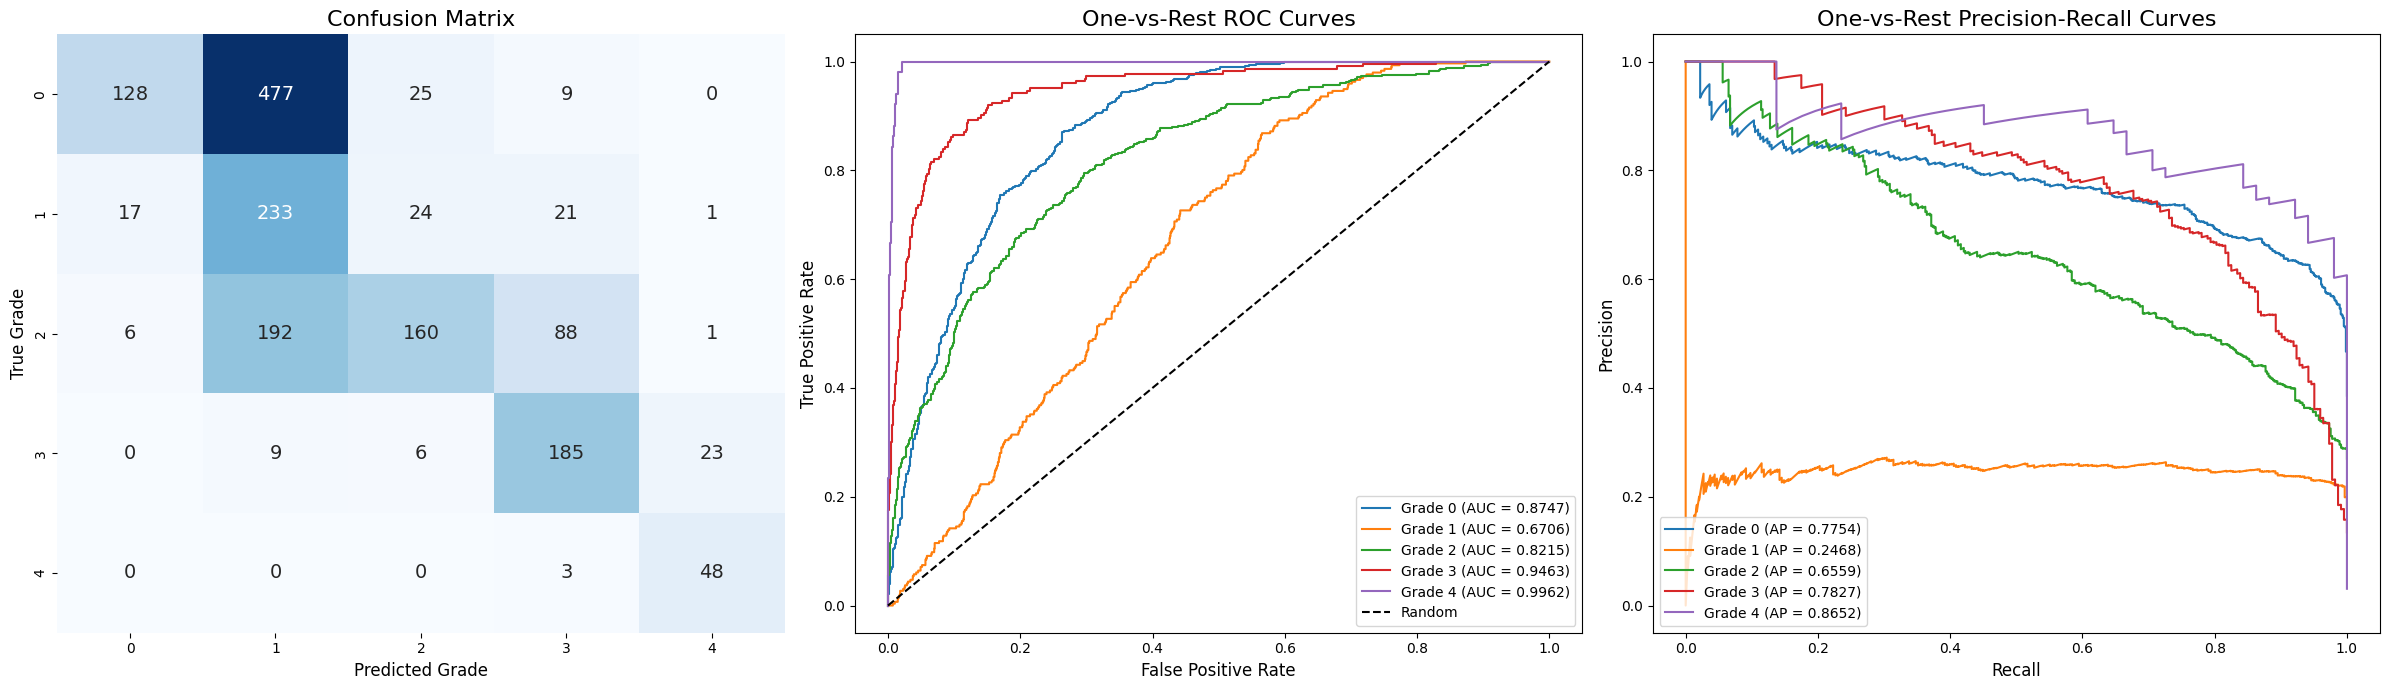

In [ ]:
# 3. Plotting Diagrams
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    has_sns = True
except ImportError:
    has_sns = False

plt.figure(figsize=(24, 7))

# Plot 1: Confusion Matrix
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_true, y_pred)
if has_sns:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(5)], yticklabels=[str(i) for i in range(5)], cbar=False, annot_kws={"size": 14})
else:
    plt.imshow(cm, cmap='Blues')
    for i in range(5):
        for j in range(5):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Grade", fontsize=12)
plt.ylabel("True Grade", fontsize=12)

# Plot 2: ROC Curves (OVR)
plt.subplot(1, 3, 2)
for i in range(5):
    fpr, tpr, _ = roc_curve(y_one_hot[:, i], y_probas[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Grade {i} (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.title("One-vs-Rest ROC Curves", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")

# Plot 3: Precision-Recall Curves (OVR)
plt.subplot(1, 3, 3)
for i in range(5):
    precision, recall, _ = precision_recall_curve(y_one_hot[:, i], y_probas[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"Grade {i} (AP = {pr_auc:.4f})")
plt.title("One-vs-Rest Precision-Recall Curves", fontsize=16)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

## 13. Native Class Activation Maps

The five 1x1-convolution outputs are grade-specific spatial evidence maps, and global spatial averaging of those maps produces the five logits. The positive native CAM is therefore part of the classifier itself, not a post-hoc gradient approximation. Every overlay uses the exact deterministic, laterality-canonicalized image used for inference.


In [ ]:
def prepare_native_cam_input(image_path):
    """Preserve natural orientation for display, inference, and native CAM."""
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise IOError(f"Could not read image: {image_path}")
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    spatial_transform = transforms.Compose([
        SquarePadOpenCV(),
        OpenCVCLAHE(),
        transforms.ToPILImage(),
        transforms.Resize((TrainingConfig.img_size, TrainingConfig.img_size)),
        transforms.CenterCrop(TrainingConfig.crop_size),
    ])
    display_image = np.asarray(spatial_transform(image_rgb))
    tensor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])(display_image).unsqueeze(0).to(device)
    return display_image, tensor


def cam_energy_summary(cam):
    """Report the same joint and border enrichment definitions used in the ablation."""
    height, width = cam.shape
    joint_mask = np.zeros_like(cam, dtype=bool)
    joint_mask[int(0.28 * height):int(0.72 * height), int(0.06 * width):int(0.94 * width)] = True
    border_mask = np.ones_like(cam, dtype=bool)
    border_mask[int(0.08 * height):int(0.92 * height), int(0.08 * width):int(0.92 * width)] = False
    total = cam.sum() + 1e-8
    joint_energy = float(cam[joint_mask].sum() / total)
    border_energy = float(cam[border_mask].sum() / total)
    return {
        "joint_energy": joint_energy,
        "joint_enrichment": joint_energy / float(joint_mask.mean()),
        "border_energy": border_energy,
        "border_enrichment": border_energy / float(border_mask.mean()),
    }


In [ ]:
def native_cam_overlay(display_image, cam, alpha=0.40):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(display_image, 1.0 - alpha, heatmap, alpha, 0)


def show_native_cams(image_path, model, true_grade=None):
    """Show predicted- and true-grade positive evidence without gradient hooks."""
    display_image, tensor = prepare_native_cam_input(image_path)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probabilities = F.softmax(logits.float(), dim=1)[0]
        predicted_grade = int(probabilities.argmax().item())

    target_grades = [predicted_grade]
    if true_grade is not None:
        target_grades.append(int(true_grade))
    else:
        target_grades.append(predicted_grade)

    cams, summaries = [], []
    for grade in target_grades:
        native_cam, _, _ = model.native_cam(tensor, class_index=grade)
        cam = native_cam[0].cpu().numpy()
        cams.append(cam)
        summaries.append(cam_energy_summary(cam))

    figure, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(display_image)
    axes[0].set_title(
        f"Processed knee | true G{true_grade}" if true_grade is not None else "Processed knee"
    )
    axes[1].imshow(native_cam_overlay(display_image, cams[0]))
    axes[1].set_title(
        f"Predicted G{predicted_grade} evidence | p={probabilities[predicted_grade]:.3f}"
    )
    axes[2].imshow(native_cam_overlay(display_image, cams[1]))
    true_title = int(true_grade) if true_grade is not None else predicted_grade
    axes[2].set_title(
        f"True G{true_title} evidence | p={probabilities[true_title]:.3f}"
    )
    for axis in axes:
        axis.axis("off")
    figure.tight_layout()
    plt.show()

    predicted_summary = summaries[0]
    print(
        f"Predicted-map joint enrichment={predicted_summary['joint_enrichment']:.3f}; "
        f"border enrichment={predicted_summary['border_enrichment']:.3f}"
    )
    if predicted_summary["border_enrichment"] > 0.85:
        print("Review warning: predicted-class positive evidence is unusually border-heavy.")
    return {
        "predicted_grade": predicted_grade,
        "probabilities": probabilities.cpu().numpy(),
        "predicted_cam": cams[0],
        "true_cam": cams[1],
        "predicted_cam_metrics": predicted_summary,
        "true_cam_metrics": summaries[1],
    }


Loading native-CAM model weights from: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_04-34-08_758611_UTC_natural_orientation_flip_gamma_ema/best_model.pth

--- Native CAM for true Grade 0 ---


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


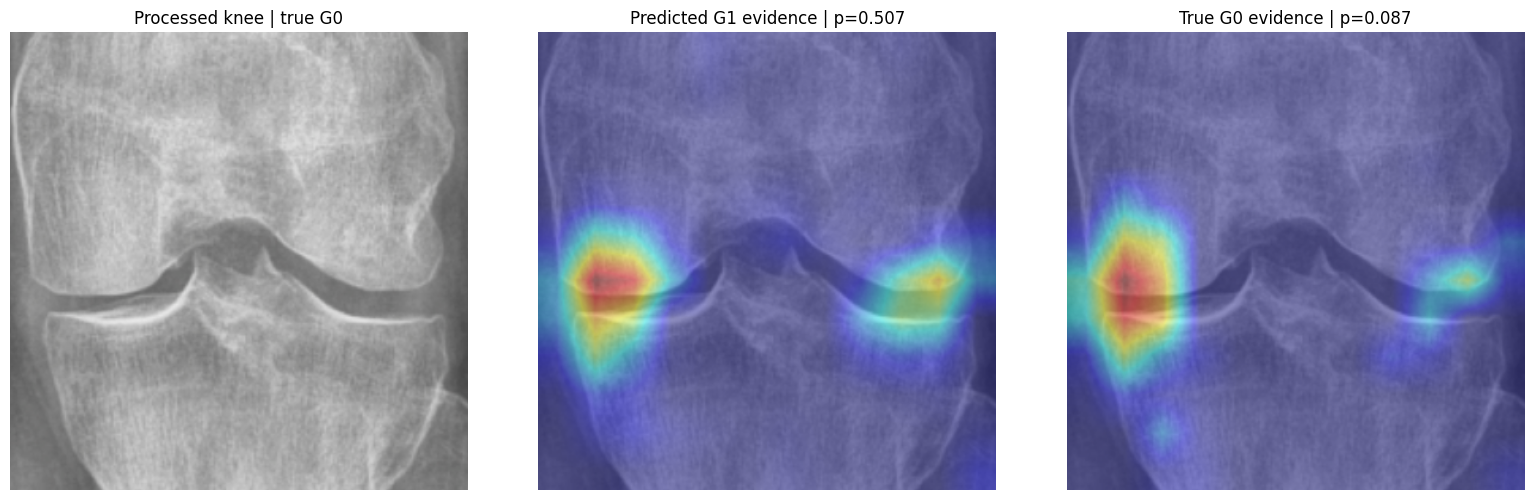

Predicted-map joint enrichment=2.028; border enrichment=0.563

--- Native CAM for true Grade 1 ---


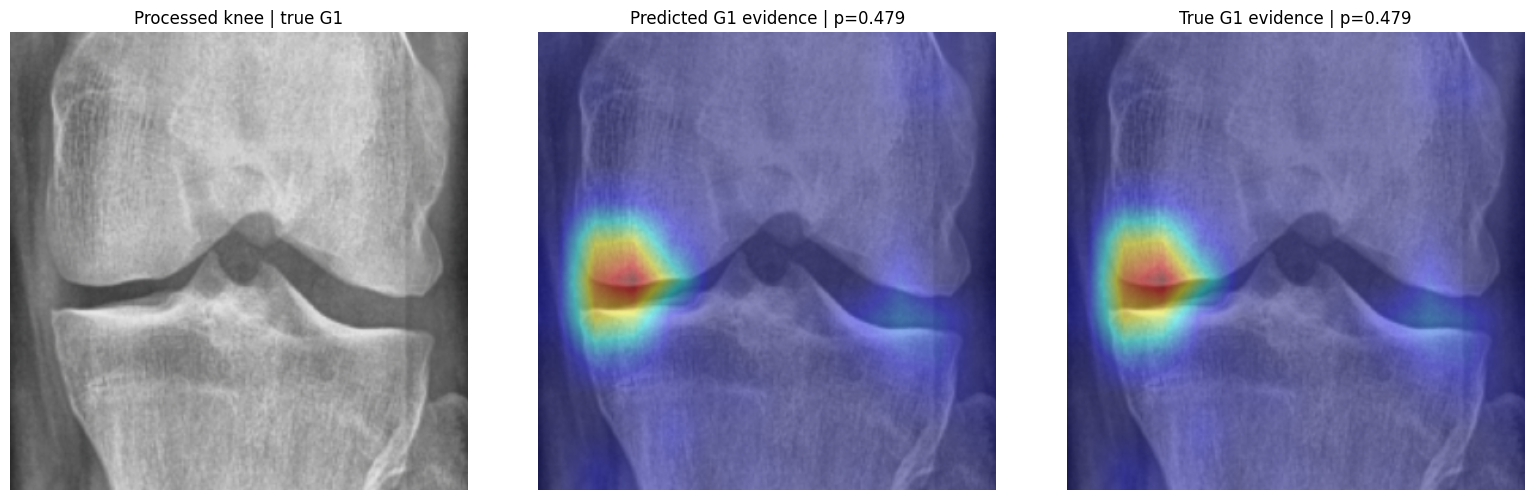

Predicted-map joint enrichment=2.059; border enrichment=0.393

--- Native CAM for true Grade 2 ---


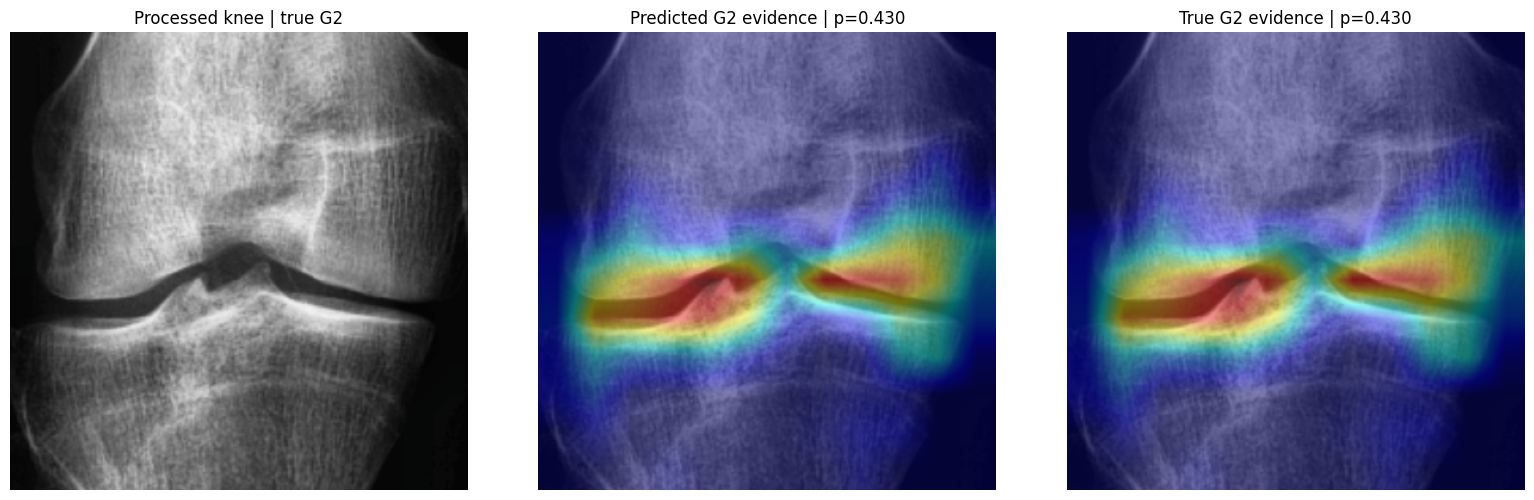

Predicted-map joint enrichment=2.216; border enrichment=0.325

--- Native CAM for true Grade 3 ---


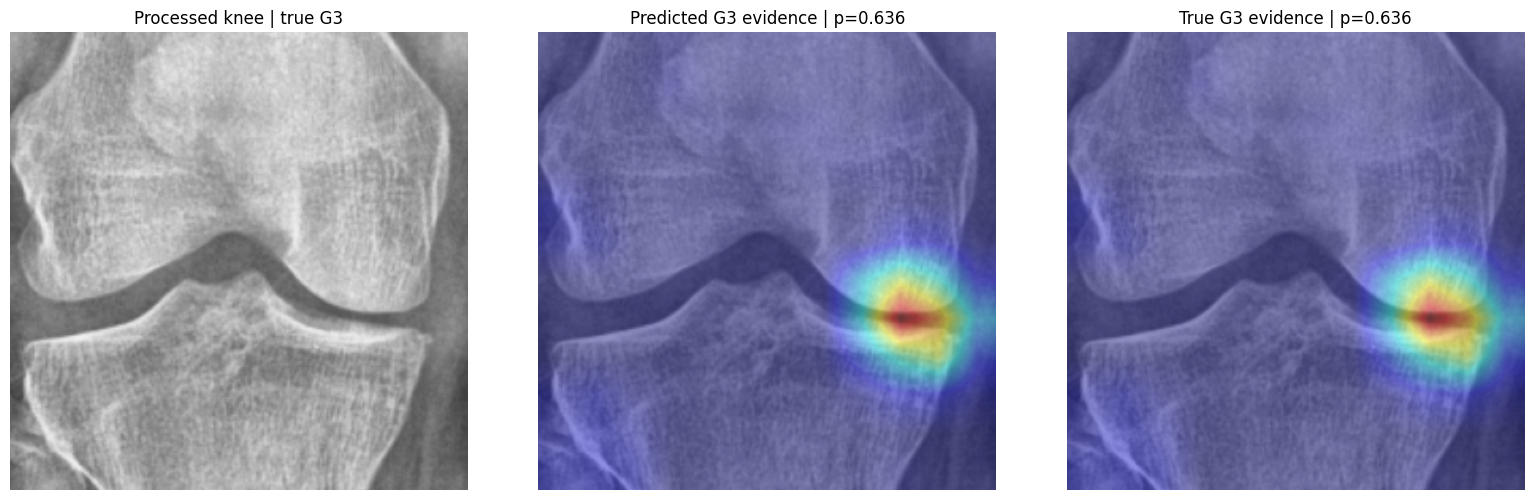

Predicted-map joint enrichment=1.759; border enrichment=0.647

--- Native CAM for true Grade 4 ---


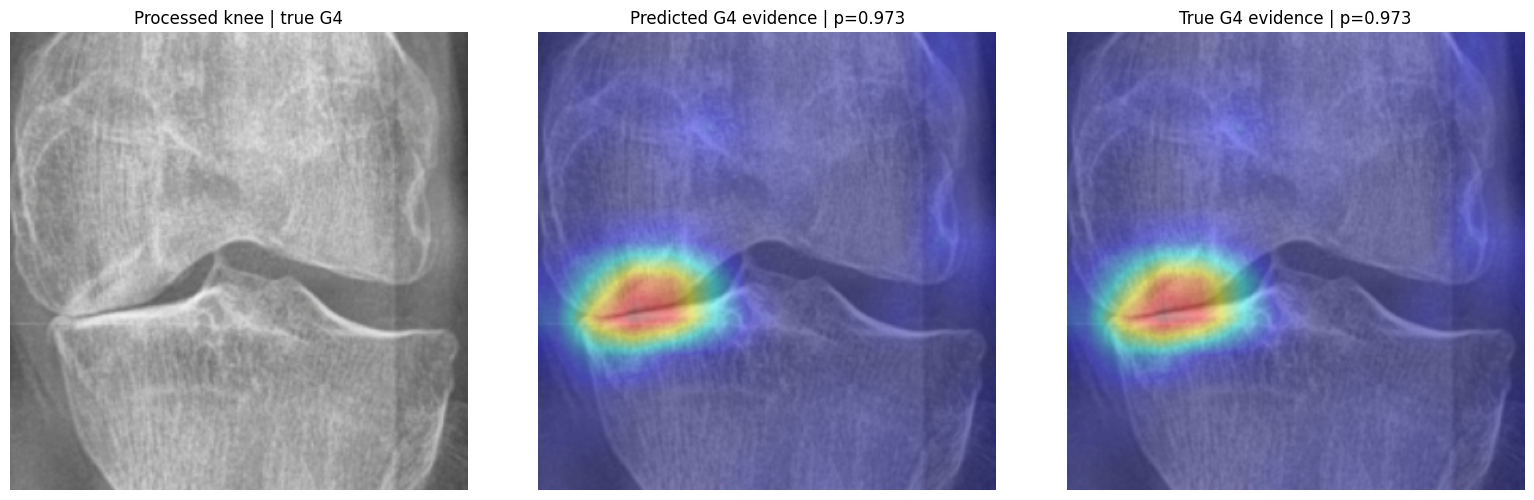

Predicted-map joint enrichment=1.812; border enrichment=0.546

--- Misclassified validation case 0 ---


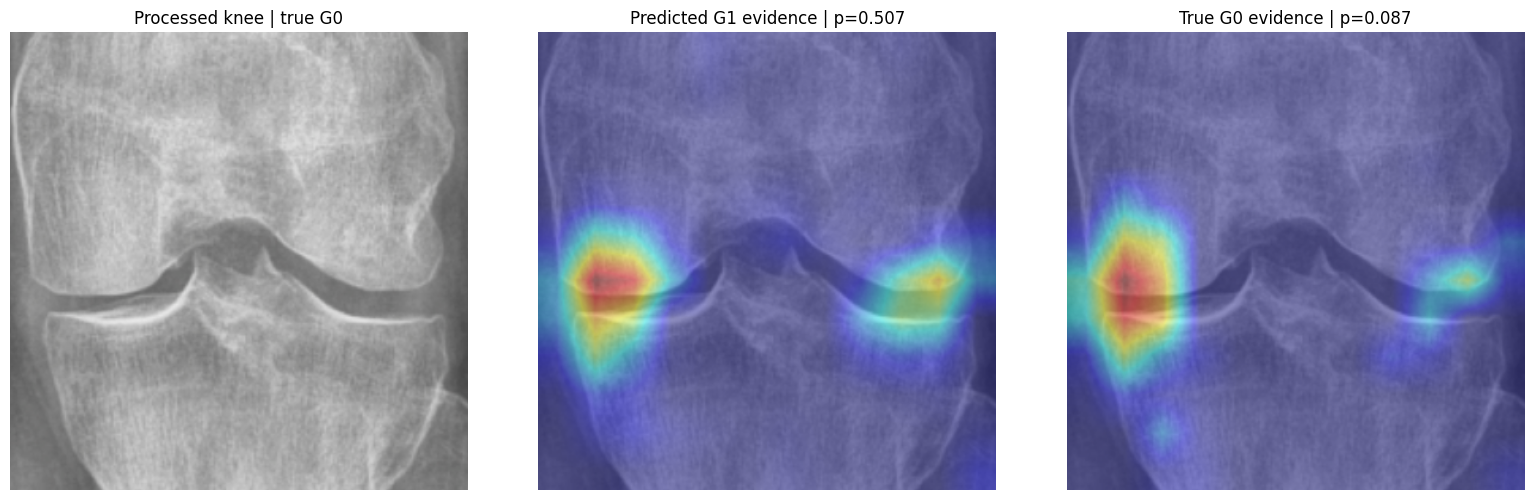

Predicted-map joint enrichment=2.028; border enrichment=0.563

--- Misclassified validation case 1 ---


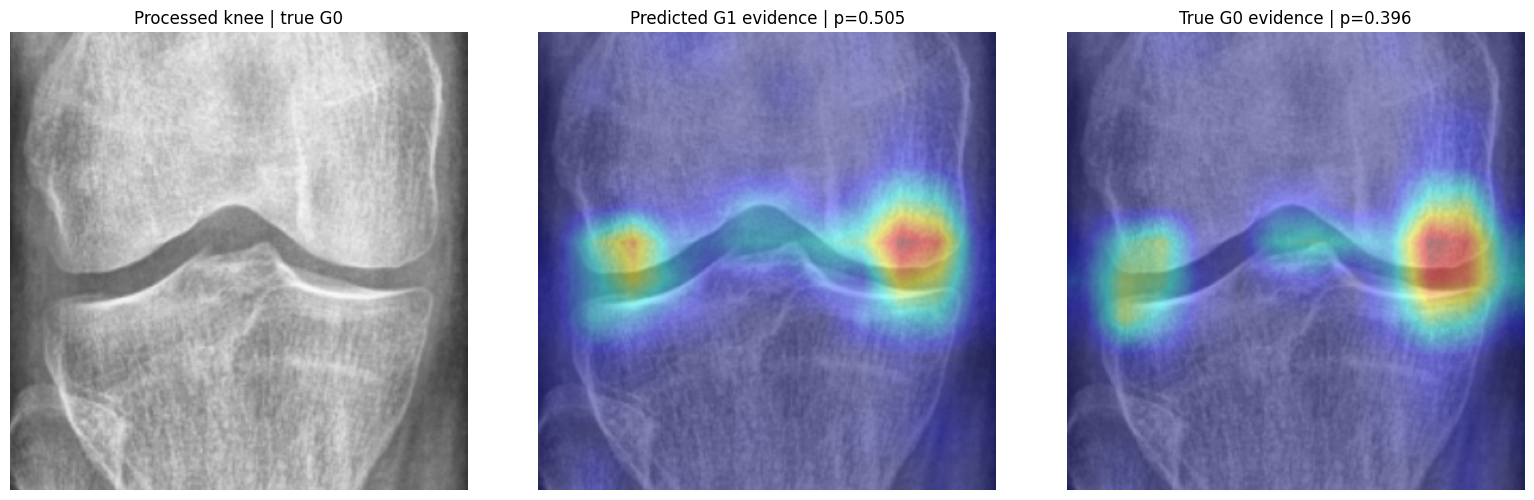

Predicted-map joint enrichment=2.233; border enrichment=0.353

--- Misclassified validation case 3 ---


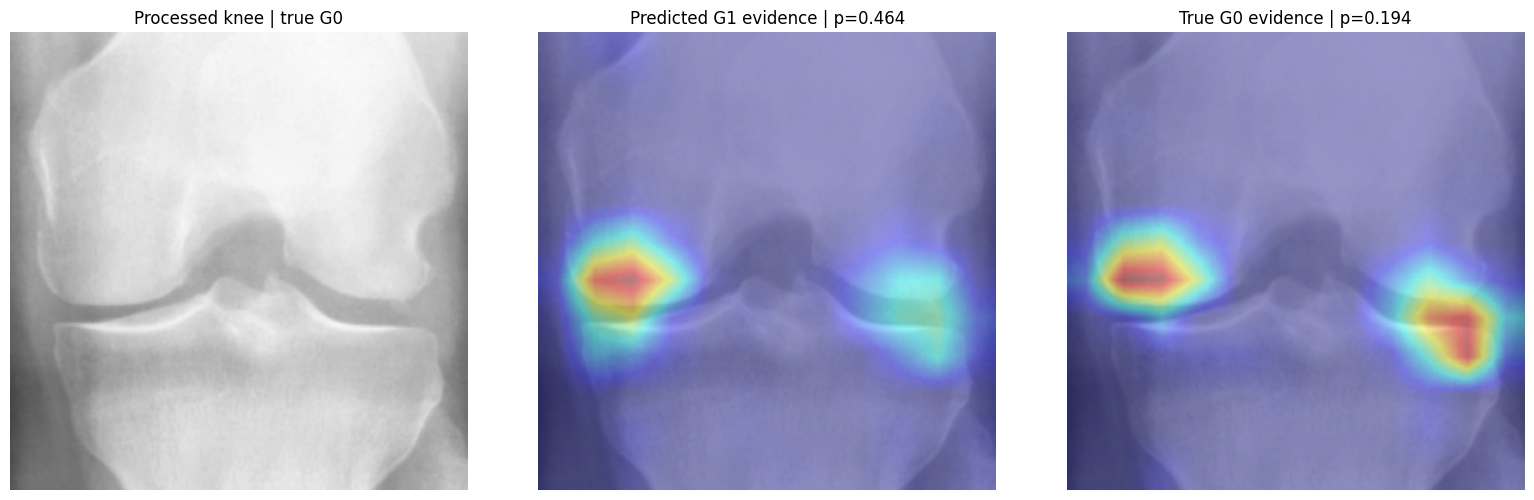

Predicted-map joint enrichment=2.156; border enrichment=0.401

--- Misclassified validation case 5 ---


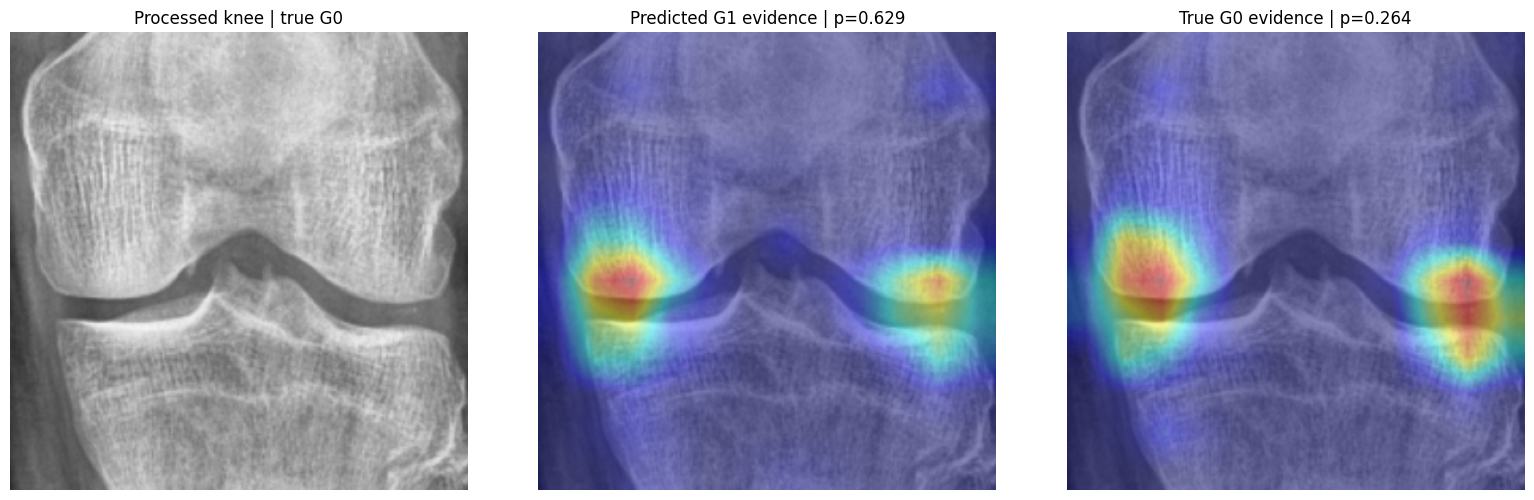

Predicted-map joint enrichment=1.964; border enrichment=0.572

--- Misclassified validation case 6 ---


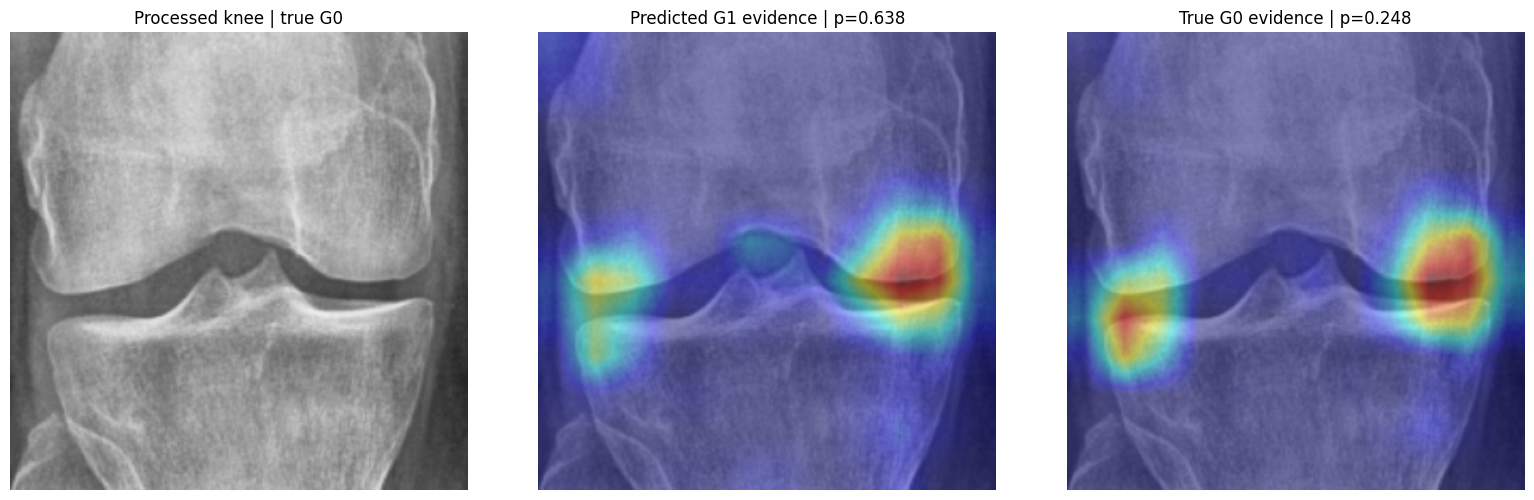

Predicted-map joint enrichment=2.031; border enrichment=0.543


In [ ]:
# Load the exact best checkpoint selected from validation metrics.
loss_type_current = TrainingConfig.loss_stage3 if TrainingConfig.training_pipeline == "3-stage" else TrainingConfig.loss_standard
best_model = DenseNet121Model(
    num_classes=TrainingConfig.num_classes,
    pretrained=False,
    loss_type=loss_type_current,
).to(device)

best_weight_path = stage3_best_path
if not os.path.exists(best_weight_path):
    raise FileNotFoundError(f"Final model checkpoint not found: {best_weight_path}")

print(f"Loading native-CAM model weights from: {best_weight_path}")
try:
    checkpoint = torch.load(best_weight_path, map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load(best_weight_path, map_location=device)
best_model.load_state_dict(checkpoint.get("model_state_dict", checkpoint))
best_model.eval()

# One deterministic validation example per true grade.
class_indices = {grade: None for grade in range(TrainingConfig.num_classes)}
for index, label in enumerate(val_dataset.labels):
    if class_indices[label] is None:
        class_indices[label] = index

for grade, index in sorted(class_indices.items()):
    if index is not None:
        print(f"\n--- Native CAM for true Grade {grade} ---")
        show_native_cams(
            val_dataset.image_paths[index], best_model, true_grade=grade
        )

# Find several validation mistakes and compare the evidence for predicted vs true grade.
misclassified_indices = []
offset = 0
with torch.no_grad():
    for images, labels in val_loader:
        predictions = best_model(images.to(device, non_blocking=True)).argmax(dim=1).cpu()
        for local_index, (prediction, label) in enumerate(zip(predictions, labels)):
            if int(prediction) != int(label):
                misclassified_indices.append(offset + local_index)
                if len(misclassified_indices) >= 5:
                    break
        offset += len(labels)
        if len(misclassified_indices) >= 5:
            break

for index in misclassified_indices:
    true_grade = int(val_dataset.labels[index])
    print(f"\n--- Misclassified validation case {index} ---")
    show_native_cams(
        val_dataset.image_paths[index], best_model, true_grade=true_grade
    )


In [ ]:
# =========================================================================
# 14. DIAGNOSTIC ERROR ANALYSIS & CRITICAL MISS DETECTOR
# =========================================================================
import os
import shutil
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

def run_error_analysis(model, val_loader, dataset_root, output_dir=None):
    """
    Diagnoses misclassifications on the validation set, copying critical failure
    cases (e.g. underpredicted severe OA) to categorized diagnostic folders for inspection.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    # Create subfolders for specific failure categories
    categories = [
        "critical_miss_underpredict",  # True Grade 3/4 predicted as 0/1
        "critical_miss_overpredict",   # True Grade 0/1 predicted as 3/4
        "boundary_confusion",          # Confusions off by exactly 1 grade
        "other_errors"                 # The rest of the mismatches
    ]
    
    if output_dir is None:
        output_dir = os.path.join(TrainingConfig.checkpoint_dir, "error_analysis_diagnostics")
    shutil.rmtree(output_dir, ignore_errors=True)
    os.makedirs(output_dir, exist_ok=True)
    for cat in categories:
        os.makedirs(os.path.join(output_dir, cat), exist_ok=True)
        
    error_log = []
    dataset = val_loader.dataset
    
    # Get correct prediction function depending on loss type
    loss_type = TrainingConfig.loss_stage3 if TrainingConfig.training_pipeline == "3-stage" else TrainingConfig.loss_standard
    predict_fn = get_prediction_helper(loss_type)
    
    print("\n[Diagnostic Engine] Running batch inference on validation set...")
    with torch.no_grad():
        for idx, (images, targets) in enumerate(tqdm(val_loader)):
            images = images.to(device)
            outputs = model(images)
            preds = predict_fn(outputs).cpu().numpy()
            targets = targets.cpu().numpy()
            
            # Extract probabilities
            if loss_type in ["corn", "focal_corn", "threshold", "coral"]:
                # Sigmoid activation for ordinal models
                probs = torch.sigmoid(outputs).cpu().numpy()
            else:
                # Softmax activation for standard CrossEntropy
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                
            for i in range(len(preds)):
                pred = int(preds[i])
                target = int(targets[i])
                
                if pred != target:
                    # Map back to the absolute original image path
                    global_idx = idx * val_loader.batch_size + i
                    if global_idx < len(dataset):
                        img_path = dataset.image_paths[global_idx]
                        
                        # Categorize the severity of the failure
                        if target in [3, 4] and pred in [0, 1]:
                            cat = "critical_miss_underpredict"
                        elif target in [0, 1] and pred in [3, 4]:
                            cat = "critical_miss_overpredict"
                        elif abs(target - pred) == 1:
                            cat = "boundary_confusion"
                        else:
                            cat = "other_errors"
                            
                        # Generate formatted diagnostic file name
                        img_name = os.path.basename(img_path)
                        prob_val = probs[i][pred] if pred < len(probs[i]) else 0.0
                        new_name = f"true_G{target}_pred_G{pred}_conf_{prob_val:.2f}_{img_name}"
                        dest_path = os.path.join(output_dir, cat, new_name)
                        
                        # Copy original image to the correct category subfolder
                        shutil.copy(img_path, dest_path)
                        
                        error_log.append({
                            "filename": img_name,
                            "original_path": img_path,
                            "true_grade": target,
                            "predicted_grade": pred,
                            "confidence": prob_val,
                            "error_category": cat
                        })
                        
    df_errors = pd.DataFrame(error_log)
    csv_path = os.path.join(output_dir, "error_analysis_log.csv")
    df_errors.to_csv(csv_path, index=False)
    
    # Output Summary Diagnostics to Console
    print("\n" + "="*60)
    print("          DIAGNOSTIC ERROR ANALYSIS RESULTS")
    print("="*60)
    print(f"Total Validation Failures: {len(df_errors)} / {len(dataset)} ({len(df_errors)/len(dataset)*100:.2f}% error)")
    
    if not df_errors.empty:
        print("\nDistribution by Severity Category:")
        print(df_errors["error_category"].value_counts().to_string())
        
        print("\nTop 5 Most Common Confusions (True vs Pred):")
        confusion_matrix_summary = df_errors.groupby(["true_grade", "predicted_grade"]).size().reset_index(name="count")
        print(confusion_matrix_summary.sort_values(by="count", ascending=False).head(5).to_string(index=False))
        
        print(f"\nSaved diagnostic images and CSV index to: {os.path.abspath(output_dir)}/")
    print("="*60)


In [ ]:
# Load best stage 3 model and analyze errors
best_model_path = stage3_best_path
if os.path.exists(best_model_path):
    print(f"Loading best model parameters from: {best_model_path}")
    try:
        checkpoint_s3 = torch.load(best_model_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint_s3 = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint_s3['model_state_dict'])
    
    # Run the error analysis
    run_error_analysis(model, val_loader, DATASET_ROOT_PATH)
else:
    print(f"Error: SOTA Stage 3 weights not found at {best_model_path}. Run training first.")


Loading best model parameters from: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_04-34-08_758611_UTC_natural_orientation_flip_gamma_ema/best_model.pth

[Diagnostic Engine] Running batch inference on validation set...


100%|██████████| 18/18 [00:14<00:00,  1.23it/s]



          DIAGNOSTIC ERROR ANALYSIS RESULTS
Total Validation Failures: 459 / 826 (55.57% error)

Distribution by Severity Category:
error_category
boundary_confusion            423
critical_miss_overpredict      20
other_errors                   12
critical_miss_underpredict      4

Top 5 Most Common Confusions (True vs Pred):
 true_grade  predicted_grade  count
          0                1    243
          2                1     91
          2                3     46
          3                2     12
          3                4     12

Saved diagnostic images and CSV index to: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_04-34-08_758611_UTC_natural_orientation_flip_gamma_ema/error_analysis_diagnostics/


## Timestamped Natural-Orientation EMA Report

The report records the exact natural-orientation augmentation policy, selected EMA
checkpoint, validation metrics, test metrics, and native-CAM interpretation.


In [ ]:
# Export an exact timestamped Markdown report for this completed run.
import json
from sklearn.metrics import precision_recall_fscore_support, recall_score

selected_checkpoint = torch.load(
    stage3_best_path, map_location="cpu", weights_only=False
)
selected_validation_raw = selected_checkpoint.get("validation_metrics", {})
selected_validation = {}
for key, value in selected_validation_raw.items():
    if key in {"probas", "report"}:
        continue
    if isinstance(value, (np.floating, np.integer)):
        value = value.item()
    selected_validation[key] = value
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3, 4],
    average="macro",
    zero_division=0,
)
test_grade1_recall = recall_score(
    y_true == 1, y_pred == 1, zero_division=0
)
manifest = {
    "run_timestamp": TrainingConfig.run_timestamp,
    "run_directory": TrainingConfig.checkpoint_dir,
    "architecture": TrainingConfig.architecture,
    "loss": "cross_entropy",
    "orientation_policy": "natural_no_inference_mirroring",
    "augmentation": {
        "horizontal_flip_probability": TrainingConfig.horizontal_flip_p,
        "rotation_degrees": TrainingConfig.rotation_degrees,
        "gamma_probability": TrainingConfig.gamma_probability,
        "gamma_range": list(TrainingConfig.gamma_range),
        "gaussian_noise_probability": 0.0,
    },
    "best_epoch": selected_checkpoint.get("epoch"),
    "selected_checkpoint": stage3_best_path,
    "validation_metrics": selected_validation,
    "test_metrics": {
        "accuracy": float(test_acc),
        "qwk": float(test_qwk),
        "macro_precision": float(test_precision),
        "macro_recall": float(test_recall),
        "macro_f1": float(test_f1),
        "grade1_recall": float(test_grade1_recall),
        "macro_ap": float(test_ap),
        "macro_auc": float(test_auc),
    },
}
with open(os.path.join(CHECKPOINT_SAVE_DIR, "run_manifest.json"), "w") as handle:
    json.dump(manifest, handle, indent=2)
with open(os.path.join(CHECKPOINT_SAVE_DIR, "SELECTED_CHECKPOINT.txt"), "w") as handle:
    handle.write(stage3_best_path + "\n")

report = f"""# DenseNet-121 Natural-Orientation EMA Run Report

| Field | Value |
| --- | --- |
| Run timestamp | {TrainingConfig.run_timestamp} |
| Architecture | `{TrainingConfig.architecture}` |
| Loss | Cross-entropy |
| Input | Resize {TrainingConfig.img_size}, crop {TrainingConfig.crop_size} |
| Batch size | {TrainingConfig.batch_size} |
| Sampler | Full inverse-frequency |
| Orientation | Natural; no deterministic inference mirroring |
| Horizontal flip | p={TrainingConfig.horizontal_flip_p:.2f}, training only |
| Gamma | {TrainingConfig.gamma_range}, p={TrainingConfig.gamma_probability:.2f} |
| Gaussian noise | Disabled |
| EMA decay | {TrainingConfig.ema_decay} |
| Best epoch | {selected_checkpoint.get('epoch')} |
| Selected checkpoint | `{stage3_best_path}` |

## Validation Selection Metrics

```json
{json.dumps(selected_validation, indent=2)}
```

## Test Metrics

| Accuracy | QWK | Macro Precision | Macro Recall | Macro F1 | Grade 1 Recall | AP | AUC |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| {test_acc:.4f} | {test_qwk:.4f} | {test_precision:.4f} | {test_recall:.4f} | {test_f1:.4f} | {test_grade1_recall:.4f} | {test_ap:.4f} | {test_auc:.4f} |

The displayed heatmap is the predicted-grade native class map from the spatially
linear classifier head. It represents model evidence, not an expert lesion mask.
"""
report_path = os.path.join(CHECKPOINT_SAVE_DIR, "report.md")
with open(report_path, "w", encoding="utf-8") as handle:
    handle.write(report)
print(f"Run report saved: {report_path}")


Run report saved: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_04-34-08_758611_UTC_natural_orientation_flip_gamma_ema/report.md


## Release Colab Runtime

The next cell releases the accelerator after training, evaluation, Grad-CAM, and diagnostics finish.


In [ ]:
# Release the Colab accelerator only after every export has completed.
try:
    from google.colab import runtime
    print("All notebook work completed. Releasing the Colab runtime...")
    runtime.unassign()
except ImportError:
    print("Not running in Google Colab; runtime release skipped.")


All notebook work completed. Releasing the Colab runtime...
